In [1]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.5.1+cu121
CUDA Available: True
CUDA Version: 12.1
GPU Name: NVIDIA RTX A4000


In [2]:
# ============================================================
# Step 1 — Environment, Imports, Reproducibility, and Runtime Setup
# Target Architecture: E-STDC (STDC Base Network + SwiftFormer EPNet Postprocessing)
# Target Dataset: CamVid (11 semantic classes)
# Optimization Mode: VRAM-Armored Mixed Precision Training
# ============================================================

import os
import cv2
import gc
import math
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Strict CUDA memory behavior to prevent fragmentation on 16GB VRAM
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models 

# Schedulers & Data Loading
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset, DataLoader

# VRAM Optimization Tools (AMP)
from torch.amp import GradScaler

import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

# --------------------------------------------------
# Cleanup and Warning Control
# --------------------------------------------------
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

warnings.filterwarnings("ignore", category=UserWarning)

# --------------------------------------------------
# Reproducibility Setup
# --------------------------------------------------
SEED = 42

def set_seed(seed: int = 42, deterministic: bool = False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

set_seed(SEED, deterministic=False)
print(f"[*] Seed set to {SEED} (deterministic=False for stable/efficient training)")

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# --------------------------------------------------
# Matplotlib & Seaborn Styling Setup
# --------------------------------------------------
%matplotlib inline
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=0.9)

# --------------------------------------------------
# Device & Engine Configuration
# --------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Using Device: {DEVICE}")

if torch.cuda.is_available():
    print(f"    GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"    CUDA Toolchain Version: {torch.version.cuda}")
    print(f"    Total Available GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print("    TF32 matrix operations enabled successfully.")
    except Exception as e:
        print(f"    TF32 configuration skipped: {e}")

# --------------------------------------------------
# Strategy Variables for E-STDC
# --------------------------------------------------
PHYSICAL_BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 2  # 4 * 2 = 8 Effective Batch Size
NUM_CLASSES = 11      # CamVid target evaluation categories
CROP_HEIGHT = 720     # Based on CamVid proportions in the paper
CROP_WIDTH = 960

USE_AMP = torch.cuda.is_available()
scaler = GradScaler("cuda" if torch.cuda.is_available() else "cpu", enabled=USE_AMP)

print(f"[*] Mixed Precision Training Enabled: {USE_AMP}")
print(f"[*] Targeting Effective Batch Size: {PHYSICAL_BATCH_SIZE * GRAD_ACCUM_STEPS}")
print(f"[*] Input Resolution Set To: {CROP_HEIGHT}x{CROP_WIDTH}")

# --------------------------------------------------
# CENTRALIZED DIRECTORY & PATH MAPPING (CamVid)
# --------------------------------------------------
DATASET_ROOT = Path("/home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/CamVid")

FINAL_SAVE_DIR = Path("/home/hrusikesh-nishank/Pictures/E-stdc_camvid/Results_Export_E-stdc_camvid") 
QUAL_VIS_DIR = Path("/home/hrusikesh-nishank/Pictures/E-stdc_camvid/training_visuals_E-stdc_camvid")

CHECKPOINT_DIR = FINAL_SAVE_DIR / "progressive_checkpoints_E-stdc_camvid"
PLOTS_DIR = FINAL_SAVE_DIR / "training_plots_E-stdc_camvid"
LOGS_DIR = FINAL_SAVE_DIR / "training_logs_E-stdc_camvid"
METRICS_DIR = FINAL_SAVE_DIR / "training_metrics_E-stdc_camvid"

for d in [CHECKPOINT_DIR, PLOTS_DIR, LOGS_DIR, METRICS_DIR, FINAL_SAVE_DIR, QUAL_VIS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Model Specifications
# --------------------------------------------------
MODEL_NAME = "E-STDC1" 
MODEL_ALIAS = "E-STDC (STDC1 Base + SwiftFormer EPNet Postprocessing)"

print(f"\n[*] Model Configuration Linked: {MODEL_ALIAS}")
print(f"[*] Pre-trained Model Base: {MODEL_NAME}")
print(f"[*] Global Analytical Results Save Path Linked: {FINAL_SAVE_DIR.resolve()}")

# --------------------------------------------------
# Runtime Performance Containers & Checkpoint Manager
# --------------------------------------------------
HISTORY_FILE = LOGS_DIR / "training_history.csv"

# Pre-initialized with ALL exhaustive metric keys including multi-loss fields
history = {
    "epoch": [], "phase": [], "train_total_loss": [], "train_seg_loss": [], "train_detail_loss": [], "train_epnet_loss": [],
    "train_miou": [], "train_macc": [], "train_aacc": [], "val_total_loss": [], "val_miou": [],
    "val_macc": [], "val_aacc": [], "learning_rate": [], "epoch_time_sec": [], "total_training_time_str": [],
    "train_Precision_Macro": [], "train_Recall_Macro": [], "train_F1_Macro": [], 
    "train_Precision_Micro": [], "train_Recall_Micro": [], "train_F1_Micro": [],
    "val_Precision_Macro": [], "val_Recall_Macro": [], "val_F1_Macro": [], 
    "val_Precision_Micro": [], "val_Recall_Micro": [], "val_F1_Micro": []
}

best_record = {
    "epoch": -1,
    "best_miou": -1.0,
    "best_path": str(CHECKPOINT_DIR / "model_best.pth"),
    "latest_path": str(CHECKPOINT_DIR / "model_latest.pth")
}

def save_checkpoint(epoch, model, optimizer, scaler, scheduler, history_dict, total_time, is_best=False):
    """
    Saves dual checkpoints and directly embeds the full history dictionary.
    Also exports the dictionary to CSV for external plotting immunity against power failure.
    """
    state = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
        'history': history_dict,
        'total_training_time': total_time,
        'best_record': best_record
    }
    
    pd.DataFrame(history_dict).to_csv(HISTORY_FILE, index=False)
    torch.save(state, best_record['latest_path'])
    
    if is_best:
        torch.save(state, best_record['best_path'])
        print(f"\n[+] New Best Model Saved! Val mIoU: {best_record['best_miou']:.2f}% | Epoch: {epoch}")

print("\n[*] Metrics tracking layers constructed. Global paths centralized. Checkpoint Manager ready. Step 1 sequence completed.")

[*] Seed set to 42 (deterministic=False for stable/efficient training)
[*] Using Device: cuda
    GPU Model: NVIDIA RTX A4000
    CUDA Toolchain Version: 12.1
    Total Available GPU Memory: 15.73 GB
    TF32 matrix operations enabled successfully.
[*] Mixed Precision Training Enabled: True
[*] Targeting Effective Batch Size: 8
[*] Input Resolution Set To: 720x960

[*] Model Configuration Linked: E-STDC (STDC1 Base + SwiftFormer EPNet Postprocessing)
[*] Pre-trained Model Base: E-STDC1
[*] Global Analytical Results Save Path Linked: /home/hrusikesh-nishank/Pictures/E-stdc_camvid/Results_Export_E-stdc_camvid

[*] Metrics tracking layers constructed. Global paths centralized. Checkpoint Manager ready. Step 1 sequence completed.


In [3]:
# ============================================================
# STEP 2: HYPERPARAMETERS, LABEL ENCODING, VISUALIZATION
# Target Architecture: E-STDC (STDC Base + EPNet Postprocessing)
# Target Dataset: CamVid (11 Classes)[cite: 4, 5]
# Optimization: 250 Epochs, AdamW, LR 5e-4[cite: 1], 720x960 Crops[cite: 4]
# ============================================================

import matplotlib.ticker as mtick 
import torch.nn.functional as F
from pathlib import Path
import numpy as np

print(f"[*] Dataset root inherited: {DATASET_ROOT}")
print(f"[*] Visualizations target: {QUAL_VIS_DIR.resolve()}")
print(f"[*] Final export target: {FINAL_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# CORE TASK SETTINGS (CamVid 11-Class Standard)
# ------------------------------------------------------------
CLASSES = 11
IGNORE_INDEX = 255

CLASS_NAMES = [
    "Sky", "Building", "Pole", "Road", "Pavement", 
    "Tree", "SignSymbol", "Fence", "Car", "Pedestrian", "Bicyclist"
]

# Standard CamVid RGB Color Palette for the 11 classes[cite: 5]
CAMVID_PALETTE = np.array([
    [128, 128, 128], # Sky
    [128, 0, 0],     # Building
    [192, 192, 128], # Pole
    [128, 64, 128],  # Road
    [60, 40, 222],   # Pavement
    [128, 128, 0],   # Tree
    [192, 128, 128], # SignSymbol
    [64, 64, 128],   # Fence
    [64, 0, 128],    # Car
    [64, 64, 0],     # Pedestrian
    [0, 128, 192],   # Bicyclist
], dtype=np.uint8)

# ------------------------------------------------------------
# IMAGE GEOMETRY & CROP SIZE (E-STDC CamVid Standard)
# ------------------------------------------------------------
IMG_H = 720
IMG_W = 960
VAL_IMG_H = 720  
VAL_IMG_W = 960  

# ------------------------------------------------------------
# TRAINING EPOCHS
# ------------------------------------------------------------
# Models were trained for 250 epochs in each experiment[cite: 1].
EPOCHS = 250
USE_EARLY_STOPPING = False  

# ------------------------------------------------------------
# OPTIMIZATION SCHEDULE (AdamW as specified in EPNet paper)
# ------------------------------------------------------------
# Employed an AdamW optimizer with an initial learning rate of 5x10-4 and a decay rate of 0.01 for optimization[cite: 1].
OPTIMIZER_TYPE = "AdamW"
BASE_LR = 5e-4            
WEIGHT_DECAY = 0.01       

print("\n--- E-STDC Optimization Schedule ---")
print(f"Target Total Epochs     : {EPOCHS}")
print(f"Optimizer Type          : {OPTIMIZER_TYPE}")
print(f"Base Learning Rate      : {BASE_LR}")
print(f"Weight Decay            : {WEIGHT_DECAY}")
print(f"Crop Size               : {IMG_H}x{IMG_W}")

# ------------------------------------------------------------
# VALIDATION / INFERENCE SETTINGS
# ------------------------------------------------------------
USE_SLIDING_WINDOW_VAL = False
VAL_WINDOW_SIZE = (720, 960)
VAL_WINDOW_STRIDE = (512, 512)   
USE_FLIP_TTA = True              

# ------------------------------------------------------------
# ENCODING & DECODING (CamVid 32 -> 11 Mapping)
# ------------------------------------------------------------
# The raw CamVid masks are RGB images. We map specific RGB 
# combinations down to our 11 integer class IDs[cite: 5].
CAMVID_RGB_TO_CLASS = {
    (128, 128, 128): 0,   # Sky
    (128, 0, 0): 1,       # Building
    (192, 192, 128): 2,   # Pole
    (128, 64, 128): 3,    # Road
    (60, 40, 222): 4,     # Pavement
    (128, 128, 0): 5,     # Tree
    (192, 128, 128): 6,   # SignSymbol
    (64, 64, 128): 7,     # Fence
    (64, 0, 128): 8,      # Car
    (64, 64, 0): 9,       # Pedestrian
    (0, 128, 192): 10,    # Bicyclist
}

def encode_mask(mask: np.ndarray) -> np.ndarray:
    """
    Converts a raw RGB CamVid mask into a 2D integer array containing 
    labels 0-10, and 255 for ignored/void pixels[cite: 5].
    """
    if len(mask.shape) == 2:
        encoded = mask.copy()
        encoded[(encoded > 10) & (encoded != 255)] = IGNORE_INDEX
        return encoded.astype(np.uint8)
        
    encoded = np.full(mask.shape[:2], IGNORE_INDEX, dtype=np.uint8)
    for rgb, class_id in CAMVID_RGB_TO_CLASS.items():
        match = (mask == rgb).all(axis=-1)
        encoded[match] = class_id
        
    return encoded

def decode_segmap(segmentation_map: np.ndarray) -> np.ndarray:
    h, w = segmentation_map.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    valid_mask = (segmentation_map >= 0) & (segmentation_map < CLASSES)
    for label, color in enumerate(CAMVID_PALETTE):
        rgb[segmentation_map == label] = color
    rgb[~valid_mask] = np.array([0, 0, 0], dtype=np.uint8)
    return rgb

# ------------------------------------------------------------
# PUBLICATION-READY EVALUATION CURVES
# ------------------------------------------------------------
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_training_curves(history_dict, save_path=FINAL_SAVE_DIR):
    keys_to_extract = ['epoch', 'train_total_loss', 'val_total_loss', 'train_miou', 'val_miou', 'train_F1_Macro', 'val_F1_Macro']
    safe_dict = {}
    
    target_len = len(history_dict.get('epoch', []))
    if target_len == 0: return

    for k in keys_to_extract:
        if k in history_dict:
            col = history_dict[k]
            if len(col) > target_len:
                safe_dict[k] = col[:target_len]
            elif len(col) < target_len:
                safe_dict[k] = col + [np.nan] * (target_len - len(col))
            else:
                safe_dict[k] = col
        else:
            safe_dict[k] = [np.nan] * target_len

    df = pd.DataFrame(safe_dict)

    interval_df = df[(df['epoch'] % 5 == 0) | (df['epoch'] == df['epoch'].max())].copy()
    
    if interval_df.empty: return
    epochs_filtered = interval_df['epoch'].values

    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    axes[0].plot(epochs_filtered, interval_df["train_total_loss"], marker='o', label='Train Loss', color='blue', linewidth=2)
    if not interval_df["val_total_loss"].isna().all():
        axes[0].plot(epochs_filtered, interval_df["val_total_loss"], marker='s', label='Validation Loss', color='red', linewidth=2)
    axes[0].set_title('Loss Progress', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=12)

    axes[1].plot(epochs_filtered, interval_df["train_miou"], marker='o', label='Train mIoU', color='green', linewidth=2)
    if not interval_df["val_miou"].isna().all():
        axes[1].plot(epochs_filtered, interval_df["val_miou"], marker='s', label='Validation mIoU', color='orange', linewidth=2)
    axes[1].set_title('mIoU Progress', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('mIoU', fontsize=12)
    axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
    axes[1].legend(fontsize=12)

    axes[2].plot(epochs_filtered, interval_df["train_F1_Macro"], marker='o', label='Train F1 (Macro)', color='purple', linewidth=2)
    if not interval_df["val_F1_Macro"].isna().all():
        axes[2].plot(epochs_filtered, interval_df["val_F1_Macro"], marker='s', label='Validation F1 (Macro)', color='magenta', linewidth=2)
    axes[2].set_title('F1-Score Progress', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('F1 Score', fontsize=12)
    axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
    axes[2].legend(fontsize=12)

    plt.tight_layout()
    
    combined_graph_path = save_path / "presentation_metrics_progress_ESTDC.png"
    plt.savefig(combined_graph_path, dpi=600, bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------
# QUALITATIVE VISUALIZATION (E-STDC Adapted)
# ------------------------------------------------------------
import torch

def visualize_results(loader, model, epoch, save_path=QUAL_VIS_DIR, max_images=3):
    save_path = Path(save_path)
    save_path.mkdir(parents=True, exist_ok=True)
    model.eval()

    batch = next(iter(loader))
    images, targets = batch[0], batch[1]
    images = images.to(DEVICE)
    _, _, current_h, current_w = images.shape
    
    with torch.no_grad():
        with torch.autocast(device_type="cuda", enabled=(torch.cuda.is_available() and images.is_cuda)):
            outputs = model(images)
            logits = outputs[0] if isinstance(outputs, tuple) else outputs
            logits_up = F.interpolate(logits, size=(current_h, current_w), mode="bilinear", align_corners=False)
            preds = torch.argmax(logits_up, dim=1).cpu().numpy()

    images_np = images.detach().cpu().numpy()
    targets_np = targets.cpu().numpy()

    n = min(max_images, len(images_np))
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
    if n == 1: axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = np.transpose(images_np[i], (1, 2, 0))
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(decode_segmap(targets_np[i]))
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(decode_segmap(preds[i]))
        axes[i, 2].set_title(f"E-STDC Prediction (Epoch {epoch})")
        axes[i, 2].axis("off")

    plt.tight_layout()
    out_file = save_path / f"epoch_{epoch:03d}_comparison.png"
    plt.savefig(out_file, dpi=600, bbox_inches="tight")
    plt.close(fig)

def save_visuals_every_10_epochs(epoch, loader, model, save_path=QUAL_VIS_DIR, max_images=3):
    if epoch > 0 and epoch % 10 == 0:
        visualize_results(loader, model, epoch, save_path, max_images)

print("[*] Step 2 strictly configured for E-STDC Architecture Replication on CamVid.")

[*] Dataset root inherited: /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/CamVid
[*] Visualizations target: /home/hrusikesh-nishank/Pictures/E-stdc_camvid/training_visuals_E-stdc_camvid
[*] Final export target: /home/hrusikesh-nishank/Pictures/E-stdc_camvid/Results_Export_E-stdc_camvid

--- E-STDC Optimization Schedule ---
Target Total Epochs     : 250
Optimizer Type          : AdamW
Base Learning Rate      : 0.0005
Weight Decay            : 0.01
Crop Size               : 720x960
[*] Step 2 strictly configured for E-STDC Architecture Replication on CamVid.


In [5]:
# ============================================================
# STEP 3: DATASET AND DATALOADERS (E-STDC Adapted for CamVid)
# Target Architecture: E-STDC (STDC Base + EPNet Postprocessing)
# Target Dataset: CamVid
# Optimized for: 720x960 Crops, Paper-Exact Augmentations[cite: 4]
# ============================================================

import inspect
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
import random

# Note: All major libraries (torch, cv2, albumentations, numpy), paths, 
# and mapping variables are securely inherited from Steps 1 & 2.

# ------------------------------------------------------------
# DATASET DISCOVERY FOR CAMVID
# ------------------------------------------------------------
def get_camvid_pairs(split):
    # Depending on format, it might be 'train' and 'trainannot' or 'train_labels'
    img_dir = DATASET_ROOT / split
    
    # Try different common CamVid label folder names
    if (DATASET_ROOT / f"{split}annot").exists():
        mask_dir = DATASET_ROOT / f"{split}annot"
    elif (DATASET_ROOT / f"{split}_labels").exists():
        mask_dir = DATASET_ROOT / f"{split}_labels"
    else:
        # Fallback to assuming masks are in the same folder or standard naming
        mask_dir = DATASET_ROOT / split
        
    all_imgs = sorted(list(img_dir.glob("*.png")) + list(img_dir.glob("*.jpg")))
    
    valid_imgs = []
    valid_masks = []
    
    for img_path in all_imgs:
        # CamVid masks often have no suffix, or an "_L" suffix, or just match exactly
        mask_path = mask_dir / img_path.name
        
        if not mask_path.exists():
            # Try _L.png (Another common CamVid convention)
            mask_path = mask_dir / (img_path.stem + "_L.png")
            
        if mask_path.exists():
            valid_imgs.append(img_path)
            valid_masks.append(mask_path)
            
    return valid_imgs, valid_masks

train_img_paths, train_mask_paths = get_camvid_pairs("train")
val_img_paths, val_mask_paths = get_camvid_pairs("val")

# Fallback: if 'val' is named 'test' in your specific CamVid structure
if len(val_img_paths) == 0:
    val_img_paths, val_mask_paths = get_camvid_pairs("test")

if len(train_img_paths) == 0 or len(val_img_paths) == 0:
    raise FileNotFoundError("Could not find valid CamVid image/mask pairs. Please check paths.")

print(f"\n--- CamVid Dataset Split ---")
print(f"[*] Training image/mask pairs   : {len(train_img_paths)}")
print(f"[*] Validation image/mask pairs : {len(val_img_paths)}")

# ------------------------------------------------------------
# DATASET
# ------------------------------------------------------------
class CamVidDataset(Dataset):
    def __init__(self, image_paths, mask_paths, split="train", transform=None):
        self.transform = transform
        self.split = split
        self.images = image_paths
        self.masks = mask_paths

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = str(self.images[idx])
        mask_path = str(self.masks[idx])

        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Read mask in color, then convert BGR to RGB so it matches our lookup table
        mask_raw = cv2.imread(mask_path, cv2.IMREAD_COLOR)
        if mask_raw is None:
            raise ValueError(f"Failed to read mask: {mask_path}")
            
        mask_raw = cv2.cvtColor(mask_raw, cv2.COLOR_BGR2RGB)
        
        # Inherited directly from Step 2
        mask = encode_mask(mask_raw)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        if not torch.is_tensor(image):
            image = torch.as_tensor(image).permute(2, 0, 1).float()
        
        if not torch.is_tensor(mask):
            mask = torch.as_tensor(mask, dtype=torch.long)
        else:
            mask = mask.long()

        return image, mask

# ------------------------------------------------------------
# AUGMENTATION HELPERS & TRANSFORMS (Strict Paper Replication)
# ------------------------------------------------------------
def pad_if_needed_tf(min_h, min_w, ignore_index=255):
    sig = inspect.signature(A.PadIfNeeded)
    kwargs = dict(min_height=min_h, min_width=min_w, border_mode=cv2.BORDER_CONSTANT, p=1.0)
    if "fill" in sig.parameters:
        kwargs.update(fill=0, fill_mask=ignore_index)
    else:
        kwargs.update(value=0, mask_value=ignore_index)
    return A.PadIfNeeded(**kwargs)

# The STDC paper explicitly states for CamVid:
# "the scale ranges in [0.5, 2.5] and cropped resolution is 960x720" (Width 960, Height 720)[cite: 4].
train_transform = A.Compose([
    # scale_limit relative to 1.0. (-0.5, +1.5) => [0.5, 2.5][cite: 4]
    A.RandomScale(scale_limit=(-0.5, 1.5), interpolation=cv2.INTER_LINEAR, p=1.0), 
    pad_if_needed_tf(IMG_H, IMG_W, IGNORE_INDEX),
    A.RandomCrop(height=IMG_H, width=IMG_W, p=1.0),
    A.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1, p=0.5), # Standard color jittering
    A.HorizontalFlip(p=0.5), # Random mirror/horizontal flip
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

# Validation transform runs at native resolution
val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

# ------------------------------------------------------------
# COLLATE FUNCTION 
# ------------------------------------------------------------
def dense_collate_fn(batch):
    images = torch.stack([item[0] for item in batch], dim=0)
    masks = torch.stack([item[1] for item in batch], dim=0)
    return images, masks

# ------------------------------------------------------------
# INITIALIZATION
# ------------------------------------------------------------

train_dataset = CamVidDataset(
    image_paths=train_img_paths, mask_paths=train_mask_paths, split="train",
    transform=train_transform
)

val_dataset = CamVidDataset(
    image_paths=val_img_paths, mask_paths=val_mask_paths, split="val",
    transform=val_transform
)

NUM_WORKERS = min(4, os.cpu_count() if os.cpu_count() is not None else 2)
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0

print(f"\n--- DataLoader Hardware Configuration ---")
print(f"[*] Num workers     : {NUM_WORKERS}")
print(f"[*] Pin memory      : {PIN_MEMORY}")

train_loader = DataLoader(
    train_dataset, batch_size=PHYSICAL_BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
    collate_fn=dense_collate_fn,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

val_loader = DataLoader(
    val_dataset, batch_size=1, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False,
    collate_fn=dense_collate_fn,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

# ------------------------------------------------------------
# SANITY CHECKS
# ------------------------------------------------------------
train_batch = next(iter(train_loader))
train_images, train_masks = train_batch

print("\n--- Train Batch Sanity Check ---")
print(f"[*] Images shape    : {train_images.shape} (Targeting {IMG_H}x{IMG_W})")
print(f"[*] Masks shape     : {train_masks.shape}")

val_batch = next(iter(val_loader))
val_images, val_masks = val_batch

assert train_images.shape[-2:] == (IMG_H, IMG_W), f"Expected train crop {IMG_H}x{IMG_W}, got {train_images.shape[-2:]}"

print(f"[*] Val images shape: {val_images.shape} (Native CamVid Resolution)")
print("\n[*] Step 3 configured successfully and ready to feed the E-STDC model.")


--- CamVid Dataset Split ---
[*] Training image/mask pairs   : 369
[*] Validation image/mask pairs : 100

--- DataLoader Hardware Configuration ---
[*] Num workers     : 4
[*] Pin memory      : True

--- Train Batch Sanity Check ---
[*] Images shape    : torch.Size([4, 3, 720, 960]) (Targeting 720x960)
[*] Masks shape     : torch.Size([4, 720, 960])
[*] Val images shape: torch.Size([1, 3, 720, 960]) (Native CamVid Resolution)

[*] Step 3 configured successfully and ready to feed the E-STDC model.


In [8]:
# ============================================================
# STEP 4: MODEL, OPTIMIZER, LOSS, MULTI-RATE SCHEDULER
# Target Architecture: E-STDC (STDC1 Base + EPNet Postprocessing)
# Target Dataset: CamVid
# Optimized for: Mixed-Precision, AdamW, Selective Update (SUIP), Fully Vectorized, Two-Stage Warmup
# ============================================================

import os
import math
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR

# ------------------------------------------------------------
# SAFETY CHECKS & INHERITANCE
# ------------------------------------------------------------
if "train_loader" not in globals():
    raise NameError("train_loader is not defined. Please run Step 3 first.")

DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
CLASSES = globals().get("CLASSES", 11)
IGNORE_INDEX = globals().get("IGNORE_INDEX", 255)

# Inheriting constraints from Step 2
BASE_LR = globals().get("BASE_LR", 5e-4)
WEIGHT_DECAY = globals().get("WEIGHT_DECAY", 0.01)
EPOCHS = globals().get("EPOCHS", 250)

# ============================================================
# PART 1: STDC NETWORK (BASE)
# ============================================================

class ConvX(nn.Module):
    """Conv-BN-ReLU Block used in STDC"""
    def __init__(self, in_planes, out_planes, kernel=3, stride=1):
        super(ConvX, self).__init__()
        self.conv = nn.Conv2d(in_planes, out_planes, kernel_size=kernel, stride=stride, padding=kernel//2, bias=False)
        self.bn = nn.BatchNorm2d(out_planes)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class STDCModule(nn.Module):
    """
    Short-Term Dense Concatenate Module (STDC Module).
    Iteratively halves channels to extract deep features with scalable receptive fields.
    """
    def __init__(self, in_channels, out_channels, stride):
        super(STDCModule, self).__init__()
        self.stride = stride
        
        c1 = out_channels // 2
        c2 = c1 // 2
        c3 = c2 // 2
        c4 = c3  

        self.block1 = ConvX(in_channels, c1, kernel=1, stride=1)
        self.block2 = ConvX(c1, c2, kernel=3, stride=stride)
        self.block3 = ConvX(c2, c3, kernel=3, stride=1)
        self.block4 = ConvX(c3, c4, kernel=3, stride=1)

        if stride == 2:
            self.avg_pool = nn.AvgPool2d(kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        x1 = self.block1(x)
        x2 = self.block2(x1)
        x3 = self.block3(x2)
        x4 = self.block4(x3)

        if self.stride == 2:
            x1 = self.avg_pool(x1)

        out = torch.cat([x1, x2, x3, x4], dim=1)
        return out

class AttentionRefineModule(nn.Module):
    """ARM: Refines high-level semantics via global contextual attention."""
    def __init__(self, in_channels, out_channels):
        super(AttentionRefineModule, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(out_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        feat = self.bn(self.conv(x))
        attn = self.attention(feat)
        return feat * attn

class FeatureFusionModule(nn.Module):
    """FFM: Fuses shallow spatial details with deep semantic context."""
    def __init__(self, in_channels, out_channels):
        super(FeatureFusionModule, self).__init__()
        self.convblk = ConvX(in_channels, out_channels, kernel=1)
        self.attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(out_channels, out_channels // 4, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels // 4, out_channels, kernel_size=1, bias=False),
            nn.Sigmoid()
        )

    def forward(self, fsp, fcp):
        fcat = torch.cat([fsp, fcp], dim=1)
        feat = self.convblk(fcat)
        attn = self.attention(feat)
        return feat + feat * attn

class STDCNet(nn.Module):
    """STDC1 Semantic Segmentation Network."""
    def __init__(self, num_classes=11):
        super(STDCNet, self).__init__()
        
        self.stage1 = ConvX(3, 32, kernel=3, stride=2)   # 1/2
        self.stage2 = ConvX(32, 64, kernel=3, stride=2)  # 1/4
        self.stage3 = STDCModule(64, 256, stride=2)      # 1/8
        self.stage4 = STDCModule(256, 512, stride=2)     # 1/16
        self.stage5 = STDCModule(512, 1024, stride=2)    # 1/32

        self.arm4 = AttentionRefineModule(512, 128)
        self.arm5 = AttentionRefineModule(1024, 128)
        self.ffm = FeatureFusionModule(256 + 128, 256)

        self.seg_head = nn.Sequential(
            ConvX(256, 256, kernel=3),
            nn.Conv2d(256, num_classes, kernel_size=1)
        )
        self.detail_head = nn.Sequential(
            ConvX(256, 64, kernel=3),
            nn.Conv2d(64, 1, kernel_size=1)
        )

    def forward(self, x):
        h, w = x.shape[2:]
        
        feat2 = self.stage1(x)
        feat4 = self.stage2(feat2)
        feat8 = self.stage3(feat4)
        feat16 = self.stage4(feat8)
        feat32 = self.stage5(feat16)

        feat32_arm = self.arm5(feat32)
        feat32_up = F.interpolate(feat32_arm, size=feat16.shape[2:], mode='nearest')
        
        feat16_arm = self.arm4(feat16)
        feat16_sum = feat16_arm + feat32_up
        feat16_up = F.interpolate(feat16_sum, size=feat8.shape[2:], mode='nearest')

        feat_fuse = self.ffm(feat8, feat16_up)
        
        seg_logits = self.seg_head(feat_fuse)
        detail_logits = self.detail_head(feat8)

        seg_logits = F.interpolate(seg_logits, size=(h, w), mode='bilinear', align_corners=False)
        detail_logits = F.interpolate(detail_logits, size=(h, w), mode='bilinear', align_corners=False)

        if self.training:
            return seg_logits, detail_logits
        return seg_logits

# ============================================================
# PART 2: EPNet POSTPROCESSING NETWORK
# ============================================================

class SwiftFormerBlockProxy(nn.Module):
    """
    Lightweight transformer proxy block for SwiftFormer.
    Uses Depthwise Convs + Pointwise Convs to approximate efficient local-global attention.
    """
    def __init__(self, dim):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim, bias=False)
        self.norm = nn.BatchNorm2d(dim)
        self.pwconv1 = nn.Conv2d(dim, dim * 4, kernel_size=1, bias=False)
        self.act = nn.GELU()
        self.pwconv2 = nn.Conv2d(dim * 4, dim, kernel_size=1, bias=False)

    def forward(self, x):
        res = x
        x = self.dwconv(x)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        return x + res

class EPNet(nn.Module):
    """
    Efficient Postprocessing Network (EPNet) with Dynamic Shape Checking.
    """
    def __init__(self, num_classes=11):
        super(EPNet, self).__init__()
        in_dim = num_classes + 3 
        
        self.patch_embed = nn.Sequential(
            nn.Conv2d(in_dim, 48, kernel_size=4, stride=4, padding=0, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True)
        )

        self.enc1 = SwiftFormerBlockProxy(48)   # 4x
        self.down1 = nn.Conv2d(48, 56, kernel_size=2, stride=2)
        
        self.enc2 = SwiftFormerBlockProxy(56)   # 8x
        self.down2 = nn.Conv2d(56, 112, kernel_size=2, stride=2)
        
        self.enc3 = SwiftFormerBlockProxy(112)  # 16x
        self.down3 = nn.Conv2d(112, 220, kernel_size=2, stride=2)
        
        self.enc4 = SwiftFormerBlockProxy(220)  # 32x

        self.up4 = nn.ConvTranspose2d(220, 112, kernel_size=5, stride=2, padding=2, output_padding=1)
        self.bn4 = nn.BatchNorm2d(112)
        
        self.up3 = nn.ConvTranspose2d(112, 56, kernel_size=5, stride=2, padding=2, output_padding=1)
        self.bn3 = nn.BatchNorm2d(56)
        
        self.up2 = nn.ConvTranspose2d(56, 48, kernel_size=5, stride=2, padding=2, output_padding=1)
        self.bn2 = nn.BatchNorm2d(48)
        
        self.up1 = nn.ConvTranspose2d(48, 48, kernel_size=5, stride=4, padding=2, output_padding=3) 
        self.bn1 = nn.BatchNorm2d(48)

        self.affinity_head = nn.Sequential(
            nn.Conv2d(48, 24, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(24, 12, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(12, 8, kernel_size=3, padding=1)
        )

    def forward(self, rgb, logits):
        rgb_norm = rgb / 255.0 if rgb.max() > 1.0 else rgb
        probs = F.softmax(logits, dim=1) 
        
        x = torch.cat([probs, rgb_norm], dim=1) 
        
        e1 = self.patch_embed(x)
        e1 = self.enc1(e1)
        e2 = self.down1(e1)
        e2 = self.enc2(e2)
        e3 = self.down2(e2)
        e3 = self.enc3(e3)
        e4 = self.down3(e3)
        e4 = self.enc4(e4)

        # Dynamic Shape Correction for non-power-of-2 crops (e.g. 720x960)
        d4_up = self.up4(e4)
        if d4_up.shape[2:] != e3.shape[2:]:
            d4_up = F.interpolate(d4_up, size=e3.shape[2:], mode='bilinear', align_corners=False)
        d4 = F.relu(self.bn4(d4_up)) + e3

        d3_up = self.up3(d4)
        if d3_up.shape[2:] != e2.shape[2:]:
            d3_up = F.interpolate(d3_up, size=e2.shape[2:], mode='bilinear', align_corners=False)
        d3 = F.relu(self.bn3(d3_up)) + e2

        d2_up = self.up2(d3)
        if d2_up.shape[2:] != e1.shape[2:]:
            d2_up = F.interpolate(d2_up, size=e1.shape[2:], mode='bilinear', align_corners=False)
        d2 = F.relu(self.bn2(d2_up)) + e1

        d1_up = self.up1(d2)
        if d1_up.shape[2:] != x.shape[2:]:
            d1_up = F.interpolate(d1_up, size=x.shape[2:], mode='bilinear', align_corners=False)
        d1 = F.relu(self.bn1(d1_up))

        affinity_matrix = self.affinity_head(d1)
        return affinity_matrix

# ============================================================
# PART 3: SPATIAL PROPAGATION & E-STDC WRAPPER (MEMORY OPTIMIZED)
# ============================================================

def spatial_propagation_suip(initial_logits, affinity, iters=7):
    """
    Memory-Optimized Spatial Propagation with Selective Update for Initial Predictions (SUIP).
    Calculates neighbor contributions sequentially to avoid massive 5D tensor allocations.
    """
    B, C, H, W = initial_logits.shape
    
    affinity_abs = torch.abs(affinity)
    affinity_sum = torch.sum(affinity_abs, dim=1, keepdim=True) + 1e-8
    k_neighbors = affinity / affinity_sum 
    k_center = 1.0 - torch.sum(k_neighbors, dim=1, keepdim=True) 

    active_mask = torch.argmax(initial_logits, dim=1) 
    
    class_idx = torch.arange(C, device=initial_logits.device).view(1, C, 1, 1)
    presence_mask = (active_mask.unsqueeze(1) == class_idx).any(dim=-1).any(dim=-1) 
    presence_mask = presence_mask.view(B, C, 1, 1).float() 

    M_0 = initial_logits.clone()
    M_t = M_0.clone()
    
    shifts_offsets = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]

    for t in range(iters):
        base_contrib = k_center * M_0
        neighbor_contrib = 0.0
        
        padded_M = F.pad(M_t, (1, 1, 1, 1), mode='replicate')
        
        for idx, (dx, dy) in enumerate(shifts_offsets):
            shifted = padded_M[:, :, 1+dx : 1+dx+H, 1+dy : 1+dy+W]
            neighbor_contrib = neighbor_contrib + (k_neighbors[:, idx:idx+1, :, :] * shifted)
        
        M_next_full = base_contrib + neighbor_contrib
        
        M_t = torch.where(presence_mask.bool(), M_next_full, M_t)

    return M_t

class ESTDC(nn.Module):
    """End-to-End E-STDC Architecture (STDC Base + EPNet + Propagation)."""
    def __init__(self, num_classes=11, propagation_iters=7):
        super(ESTDC, self).__init__()
        self.stdc = STDCNet(num_classes)
        self.epnet = EPNet(num_classes)
        self.propagation_iters = propagation_iters

    def forward(self, rgb):
        if self.training:
            seg_logits, detail_logits = self.stdc(rgb)
            affinity = self.epnet(rgb, seg_logits.detach())
            refined_logits = spatial_propagation_suip(seg_logits.detach(), affinity, iters=self.propagation_iters)
            return refined_logits, seg_logits, detail_logits
        else:
            seg_logits = self.stdc(rgb)
            affinity = self.epnet(rgb, seg_logits)
            refined_logits = spatial_propagation_suip(seg_logits, affinity, iters=17)
            return refined_logits

# ------------------------------------------------------------
# LOAD MODEL & OPTIMIZER (AdamW)
# ------------------------------------------------------------
model = ESTDC(num_classes=CLASSES, propagation_iters=7).to(DEVICE)
print(f"[*] Loaded E-STDC Architecture (STDC1 + EPNet + SUIP Propagation) for {CLASSES} classes.")

optimizer = optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)

# ------------------------------------------------------------
# LOSS FUNCTIONS (OHEM, Dice, BCE, CrossEntropy)
# ------------------------------------------------------------

class OHEMCrossEntropyLoss(nn.Module):
    def __init__(self, ignore_index=255, thresh=0.7, min_kept=100000):
        super(OHEMCrossEntropyLoss, self).__init__()
        self.ignore_index = ignore_index
        self.thresh = float(thresh)
        self.min_kept = int(min_kept)
        self.criterion = nn.CrossEntropyLoss(ignore_index=ignore_index, reduction='none')

    def forward(self, pred, target):
        loss = self.criterion(pred, target).view(-1)
        valid_mask = target.view(-1) != self.ignore_index
        
        valid_loss = loss[valid_mask]
        if len(valid_loss) == 0:
            return loss.sum() * 0.0
            
        sorted_loss, _ = torch.sort(valid_loss, descending=True)
        if len(sorted_loss) > self.min_kept:
            threshold = max(sorted_loss[self.min_kept].item(), self.thresh)
            valid_loss = valid_loss[valid_loss > threshold]
            
        return valid_loss.mean()

class DetailLoss(nn.Module):
    def __init__(self):
        super(DetailLoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        pred = pred.squeeze(1)
        bce_loss = self.bce(pred, target)
        
        pred_sigmoid = torch.sigmoid(pred)
        intersection = (pred_sigmoid * target).sum()
        dice_loss = 1 - (2. * intersection + 1) / (pred_sigmoid.pow(2).sum() + target.pow(2).sum() + 1)
        
        return bce_loss + dice_loss

def generate_detail_gt(masks, ignore_index=255):
    """
    Generates Laplacian Boundary Ground Truth. 
    Vectorized using grouped 2D convolutions to eliminate class looping.
    """
    B, H, W = masks.shape
    
    laplacian_kernel = torch.tensor([[-1., -1., -1.], [-1., 8., -1.], [-1., -1., -1.]], device=masks.device)
    laplacian_kernel = laplacian_kernel.view(1, 1, 3, 3).repeat(CLASSES, 1, 1, 1)
    
    valid_mask = (masks != ignore_index).float()
    
    masks_onehot = F.one_hot(torch.clamp(masks, 0, CLASSES-1), num_classes=CLASSES).permute(0, 3, 1, 2).float()
    
    boundary = F.conv2d(masks_onehot, laplacian_kernel, padding=1, groups=CLASSES)
    boundary = torch.clamp(boundary, 0, 1)
    
    detail_gt, _ = torch.max(boundary, dim=1)
    
    return detail_gt * valid_mask


seg_criterion = OHEMCrossEntropyLoss(ignore_index=IGNORE_INDEX)
detail_criterion = DetailLoss()
epnet_criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

def estdc_loss(outputs, targets, current_epoch, warmup_epochs=50):
    if isinstance(outputs, tuple):
        refined_logits, seg_logits, detail_logits = outputs
        
        loss_seg = seg_criterion(seg_logits, targets)
        detail_gt = generate_detail_gt(targets)
        loss_detail = detail_criterion(detail_logits, detail_gt)
        loss_epnet = epnet_criterion(refined_logits, targets)
        
        if current_epoch <= warmup_epochs:
            total_loss = loss_seg + loss_detail
            return total_loss, loss_seg, loss_detail, torch.tensor(0.0, device=targets.device)
        else:
            total_loss = loss_seg + loss_detail + loss_epnet
            return total_loss, loss_seg, loss_detail, loss_epnet
    else:
        return epnet_criterion(outputs, targets), None, None, None

# ------------------------------------------------------------
# SCHEDULER: PURE POLYNOMIAL DECAY
# ------------------------------------------------------------
def get_poly_scheduler(optimizer, total_steps, power=0.9):
    def lr_lambda(current_step: int):
        return (1.0 - current_step / total_steps) ** power
    return LambdaLR(optimizer, lr_lambda)

# ------------------------------------------------------------
# SYSTEM INITIALIZATION & EPOCH CALCULATION
# ------------------------------------------------------------
steps_per_epoch = math.ceil(len(train_loader) / globals().get("GRAD_ACCUM_STEPS", 2))
total_update_steps = steps_per_epoch * EPOCHS

scheduler = get_poly_scheduler(optimizer, total_update_steps, power=0.9)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n--- Unified E-STDC Architecture Initialized ---")
print(f"[*] Total parameters     : {total_params:,} (STDC + EPNet)")
print(f"[*] Trainable parameters : {trainable_params:,}")
print(f"[*] Optimizer            : AdamW (LR={BASE_LR})")
print(f"[*] Effective Steps/Epoch: {steps_per_epoch}")
print(f"[*] Target Epochs        : {EPOCHS}")

[*] Loaded E-STDC Architecture (STDC1 + EPNet + SUIP Propagation) for 11 classes.

--- Unified E-STDC Architecture Initialized ---
[*] Total parameters     : 6,757,264 (STDC + EPNet)
[*] Trainable parameters : 6,757,264
[*] Optimizer            : AdamW (LR=0.0005)
[*] Effective Steps/Epoch: 46
[*] Target Epochs        : 120


In [9]:
# ============================================================
# STEP 5: TRAINING LOOP (E-STDC Architecture)
# Target Architecture: E-STDC (STDC Base + EPNet Postprocessing)
# Target Dataset: CamVid
# Optimized for: Multi-Loss Tracking, Two-Stage Warmup, AdamW
# ============================================================

import os
import gc
import math
import time
from datetime import timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm import tqdm

# ------------------------------------------------------------
# SAFETY CHECKS & PATH INHERITANCE
# ------------------------------------------------------------
required_globals = [
    "model", "train_loader", "val_loader", "optimizer", "scheduler", "estdc_loss",
    "DEVICE", "CLASSES", "IGNORE_INDEX", "GRAD_ACCUM_STEPS", "EPOCHS", 
    "FINAL_SAVE_DIR", "QUAL_VIS_DIR", "scaler"
]
missing = [k for k in required_globals if k not in globals()]
if missing:
    print(f"[*] Warning: Missing globals {missing}. Relying on fallback defaults where possible.")

DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
USE_AMP = globals().get("USE_AMP", torch.cuda.is_available())

GRAD_CLIP_NORM = globals().get("GRAD_CLIP_NORM", 1.0) 
MIN_DELTA_MIOU = 0.001

# CamVid specific fallbacks
EPOCHS = globals().get("EPOCHS", 120) 
CLASSES = globals().get("CLASSES", 11)
IGNORE_INDEX = globals().get("IGNORE_INDEX", 255)

WARMUP_EPOCHS = 50 # Phase 1 (Base STDC) vs Phase 2 (EPNet Refinement)

# ------------------------------------------------------------
# INFERENCE (E-STDC REAL-TIME STANDARD)
# ------------------------------------------------------------
def estdc_val_inference(model, image, current_epoch, warmup_epochs=50, use_flip_tta=False):
    """
    Standard inference pass for E-STDC. 
    During the Warmup phase, we bypass the untrained EPNet and evaluate STDC directly.
    After Warmup, we evaluate the full E-STDC pipeline.
    """
    B, C, H, W = image.shape
    model.eval() 
    
    with torch.no_grad():
        with torch.autocast(device_type="cuda", enabled=USE_AMP):
            
            # If in warmup, evaluate the STDC base network only
            if current_epoch <= warmup_epochs:
                logits = model.stdc(image)
            else:
                # Full E-STDC pass with Spatial Propagation
                logits = model(image)
            
            if use_flip_tta:
                flipped_img = torch.flip(image, dims=[3])
                if current_epoch <= warmup_epochs:
                    flip_logits = model.stdc(flipped_img)
                else:
                    flip_logits = model(flipped_img)
                    
                logits += torch.flip(flip_logits, dims=[3])
                logits /= 2.0
                
            # Upsample to native resolution for metric evaluation
            logits_up = F.interpolate(logits, size=(H, W), mode="bilinear", align_corners=False)
            
    return logits_up.float()

# ------------------------------------------------------------
# EXHAUSTIVE METRICS CALCULATOR
# ------------------------------------------------------------
def compute_metrics(conf_matrix: np.ndarray):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    
    # Per-class metrics
    precision_class = tp / np.maximum(tp + fp, 1)
    recall_class = tp / np.maximum(tp + fn, 1)
    iou_class = tp / np.maximum(tp + fp + fn, 1)
    f1_class = 2 * (precision_class * recall_class) / np.maximum(precision_class + recall_class, 1e-8)

    # Macro Metrics (Averaged across classes)
    macro_precision = np.nanmean(precision_class)
    macro_recall = np.nanmean(recall_class)
    macro_f1 = np.nanmean(f1_class)
    macro_miou = np.nanmean(iou_class)

    # Micro Metrics (Aggregated globally)
    total_tp, total_fp, total_fn = tp.sum(), fp.sum(), fn.sum()
    micro_precision = total_tp / max(total_tp + total_fp, 1)
    micro_recall = total_tp / max(total_tp + total_fn, 1)
    micro_f1 = 2 * (micro_precision * micro_recall) / max(micro_precision + micro_recall, 1e-8)
    micro_miou = total_tp / max(total_tp + total_fp + total_fn, 1)

    return {
        "mIoU_Macro": float(macro_miou),
        "Precision_Macro": float(macro_precision),
        "Recall_Macro": float(macro_recall),
        "F1_Macro": float(macro_f1),
        "mIoU_Micro": float(micro_miou),
        "Precision_Micro": float(micro_precision),
        "Recall_Micro": float(micro_recall),
        "F1_Micro": float(micro_f1)
    }

def fast_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    idx = num_classes * y_true + y_pred
    return np.bincount(idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes)

def get_lr_snapshot(optimizer):
    lrs = [pg["lr"] for pg in optimizer.param_groups]
    return lrs[0], lrs[1] if len(lrs) > 1 else lrs[0]

# ------------------------------------------------------------
# CRASH RECOVERY PROTOCOL
# ------------------------------------------------------------
start_epoch = 1
global_update_step = 0
best_conf_matrix = None
best_metrics = None
training_start_time = time.time()
cumulative_training_time_sec = 0.0 

# Explicitly defining all metrics to ensure robust CSV tracking
expected_keys = [
    "epoch", "phase", "train_total_loss", "train_seg_loss", "train_detail_loss", "train_epnet_loss", 
    "train_miou", "train_macc", "train_aacc", 
    "val_total_loss", "val_miou", "val_macc", "val_aacc", 
    "learning_rate", "epoch_time_sec", "total_training_time_str",
    "train_Precision_Macro", "train_Recall_Macro", "train_F1_Macro",
    "train_Precision_Micro", "train_Recall_Micro", "train_F1_Micro",
    "val_Precision_Macro", "val_Recall_Macro", "val_F1_Macro",
    "val_Precision_Micro", "val_Recall_Micro", "val_F1_Micro"
]

# UPDATED: Changed from _cs.pt to _camvid.pt
latest_ckpt_path = FINAL_SAVE_DIR / "latest_model_estdc_camvid.pt"
best_ckpt_path = FINAL_SAVE_DIR / "best_model_estdc_camvid.pt"

if latest_ckpt_path.exists():
    print(f"\n[*] CRASH RECOVERY TRIGGERED: Found checkpoint at {latest_ckpt_path}")
    try:
        checkpoint = torch.load(latest_ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        start_epoch = checkpoint['epoch'] + 1
        global_update_step = checkpoint.get('global_update_step', 0)
        best_record = checkpoint['best_record']
        history = checkpoint['history']
        cumulative_training_time_sec = checkpoint.get('cumulative_training_time_sec', 0.0)

        target_len = start_epoch - 1
        for key in expected_keys:
            if key not in history:
                history[key] = [np.nan] * target_len
            elif len(history[key]) > target_len:
                history[key] = history[key][:target_len]
            elif len(history[key]) < target_len:
                history[key].extend([np.nan] * (target_len - len(history[key])))
                
        print(f"[*] History sanitized and synchronized. Resuming from Epoch {start_epoch}.")
    except Exception as e:
        print(f"[!] Warning: Failed to load checkpoint cleanly. Starting from scratch. Error: {e}")
        history = {k: [] for k in expected_keys}
        best_record = {"epoch": -1, "best_epoch": -1, "best_miou": -1.0, "best_path": str(best_ckpt_path), "latest_path": str(latest_ckpt_path)}
        cumulative_training_time_sec = 0.0
else:
    history = globals().get("history", {k: [] for k in expected_keys})
    best_record = globals().get("best_record", {"epoch": -1, "best_epoch": -1, "best_miou": -1.0, "best_path": str(best_ckpt_path), "latest_path": str(latest_ckpt_path)})
    cumulative_training_time_sec = 0.0

print(f"\n--- Launching E-STDC Pipeline (STDC + EPNet) on CamVid ---")
print(f"Target Epochs: {EPOCHS} (Currently at {start_epoch})")

# ------------------------------------------------------------
# MAIN LOOP
# ------------------------------------------------------------
for epoch in range(start_epoch, EPOCHS + 1):
    epoch_start_time = time.time()

    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    # ==========================
    # TRAINING PHASE
    # ==========================
    model.train()
    optimizer.zero_grad(set_to_none=True)

    train_total_loss_sum = 0.0
    train_seg_loss_sum = 0.0
    train_detail_loss_sum = 0.0
    train_epnet_loss_sum = 0.0
    train_batches = 0
    train_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    train_pbar = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False)

    for step, (images, masks) in enumerate(train_pbar, start=1):
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        _, _, curr_h, curr_w = images.shape

        with torch.autocast(device_type="cuda", enabled=USE_AMP):
            # Model returns (refined_logits, seg_logits, detail_logits) in training mode
            outputs = model(images)
            
            # Compute loss, passing current epoch to handle Two-Stage Warmup logic
            total_loss, loss_seg, loss_detail, loss_epnet = estdc_loss(
                outputs, masks, current_epoch=epoch, warmup_epochs=WARMUP_EPOCHS
            )
            
            scaled_loss = total_loss / GRAD_ACCUM_STEPS

        scaler.scale(scaled_loss).backward()
        
        train_total_loss_sum += total_loss.item()
        train_seg_loss_sum += loss_seg.item()
        train_detail_loss_sum += loss_detail.item()
        train_epnet_loss_sum += loss_epnet.item()
        train_batches += 1

        with torch.no_grad():
            # For accuracy during training, if warmup, we track STDC. If post-warmup, we track EPNet.
            if epoch <= WARMUP_EPOCHS:
                tracking_logits = outputs[1] # STDC seg_logits
            else:
                tracking_logits = outputs[0] # EPNet refined_logits
                
            logits_up = F.interpolate(tracking_logits, size=(curr_h, curr_w), mode="bilinear", align_corners=False)
            preds_np = torch.argmax(logits_up, dim=1).cpu().numpy().astype(np.int64)
            targets_np = masks.cpu().numpy().astype(np.int64)
            
            valid = (targets_np != IGNORE_INDEX)
            if valid.any():
                train_conf_matrix += fast_confusion_matrix(targets_np[valid], preds_np[valid], CLASSES)

        if (step % GRAD_ACCUM_STEPS == 0) or (step == len(train_loader)):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            
            scheduler.step()
            global_update_step += 1

        _, lr_head = get_lr_snapshot(optimizer)
        train_pbar.set_postfix(loss=f"{train_total_loss_sum / max(1, train_batches):.4f}", lr=f"{lr_head:.2e}")

    train_metrics = compute_metrics(train_conf_matrix)
    train_total_loss = train_total_loss_sum / max(1, train_batches)
    train_seg_loss = train_seg_loss_sum / max(1, train_batches)
    train_detail_loss = train_detail_loss_sum / max(1, train_batches)
    train_epnet_loss = train_epnet_loss_sum / max(1, train_batches)

    # ==========================
    # VALIDATION PHASE
    # ==========================
    model.eval()
    val_total_batches = 0
    val_total_loss_sum = 0.0
    val_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    
    val_mode_desc = "Val [Warmup: STDC Base]" if epoch <= WARMUP_EPOCHS else "Val [E-STDC Full]"
    val_pbar = tqdm(val_loader, total=len(val_loader), desc=f"Epoch {epoch}/{EPOCHS} {val_mode_desc}", leave=False)

    with torch.no_grad():
        for images, masks in val_pbar:
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            
            # Use E-STDC Inference logic (bypasses EPNet if in warmup)
            semantic_logits = estdc_val_inference(
                model, images, 
                current_epoch=epoch, warmup_epochs=WARMUP_EPOCHS, 
                use_flip_tta=globals().get("USE_FLIP_TTA", False)
            )
            
            # Loss computation on native validation resolution
            ce_loss = F.cross_entropy(semantic_logits, masks, ignore_index=IGNORE_INDEX)
            val_total_loss_sum += ce_loss.item()
            val_total_batches += 1

            preds_np = torch.argmax(semantic_logits, dim=1).cpu().numpy().astype(np.int64)
            targets_np = masks.cpu().numpy().astype(np.int64)
            
            valid = (targets_np != IGNORE_INDEX)
            if valid.any():
                val_conf_matrix += fast_confusion_matrix(targets_np[valid], preds_np[valid], CLASSES)
                
            val_metrics_preview = compute_metrics(val_conf_matrix)
            val_pbar.set_postfix(mIoU=f"{val_metrics_preview['mIoU_Macro'] * 100:.2f}%")

    val_metrics = compute_metrics(val_conf_matrix)
    val_total_loss = val_total_loss_sum / max(1, val_total_batches)

    # ------------------------------------------------------------
    # EPOCH STEP UPDATES & TIME TRACKING LOGIC
    # ------------------------------------------------------------
    epoch_time = time.time() - epoch_start_time
    cumulative_training_time_sec += epoch_time  
    
    elapsed_this_session = time.time() - training_start_time
    epochs_run_this_session = max(1, epoch - start_epoch + 1)
    eta_str = str(timedelta(seconds=int((elapsed_this_session / epochs_run_this_session) * (EPOCHS - epoch))))
    total_time_str = str(timedelta(seconds=int(cumulative_training_time_sec)))
    
    lr_backbone, lr_head = get_lr_snapshot(optimizer)

    # 1. Populate original keys for backward compatibility
    history["epoch"].append(epoch)
    history["phase"].append("train/val")
    history["learning_rate"].append(lr_head)
    history["epoch_time_sec"].append(epoch_time)
    history["total_training_time_str"].append(total_time_str)

    history["train_total_loss"].append(train_total_loss)
    history["train_seg_loss"].append(train_seg_loss)
    history["train_detail_loss"].append(train_detail_loss)
    history["train_epnet_loss"].append(train_epnet_loss)
    
    history["train_miou"].append(train_metrics["mIoU_Macro"] * 100)
    history["train_macc"].append(train_metrics["Recall_Macro"] * 100) 
    history["train_aacc"].append(train_metrics["mIoU_Micro"] * 100)   

    history["val_total_loss"].append(val_total_loss)
    history["val_miou"].append(val_metrics["mIoU_Macro"] * 100)
    history["val_macc"].append(val_metrics["Recall_Macro"] * 100)
    history["val_aacc"].append(val_metrics["mIoU_Micro"] * 100)

    # 2. Populate exhaustive metrics
    for metric_key in ["Precision_Macro", "Recall_Macro", "F1_Macro", "Precision_Micro", "Recall_Micro", "F1_Micro"]:
        history[f"train_{metric_key}"].append(train_metrics[metric_key] * 100)
        history[f"val_{metric_key}"].append(val_metrics[metric_key] * 100)

    # Console Logging
    train_phase_str = "STDC+Detail" if epoch <= WARMUP_EPOCHS else "STDC+Detail+EPNet"
    print(
        f"\nEpoch {epoch}/{EPOCHS} | Phase: {train_phase_str} | Epoch Time: {epoch_time:.2f}s | ETA: {eta_str}\n"
        f"Train Loss: {train_total_loss:.4f} (STDC: {train_seg_loss:.4f}, Detail: {train_detail_loss:.4f}, EPNet: {train_epnet_loss:.4f}) | Train mIoU: {train_metrics['mIoU_Macro']*100:.2f}%\n"
        f"Val Loss:   {val_total_loss:.4f} | Val mIoU:   {val_metrics['mIoU_Macro']*100:.2f}% | Val mAcc: {val_metrics['Recall_Macro']*100:.2f}%\n"
        f"Learning Rate: {lr_head:.2e}"
    )

    # ------------------------------------------------------------
    # STRICT 2-CHECKPOINT SAVING PROTOCOL 
    # ------------------------------------------------------------
    ckpt_dict = {
        "epoch": epoch,
        "global_update_step": global_update_step,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_record": best_record,
        "history": history,
        "cumulative_training_time_sec": cumulative_training_time_sec 
    }
    
    pd.DataFrame(history).to_csv(FINAL_SAVE_DIR / "training_history.csv", index=False)
    torch.save(ckpt_dict, latest_ckpt_path)

    improved = val_metrics["mIoU_Macro"] > (best_record["best_miou"] + MIN_DELTA_MIOU)
    if improved:
        best_record["best_epoch"] = epoch
        best_record["best_miou"] = val_metrics["mIoU_Macro"]
        best_conf_matrix = val_conf_matrix.copy()
        best_metrics = val_metrics.copy()
        
        torch.save(ckpt_dict, best_ckpt_path)
        print(f"[*] New Best Validation mIoU: {val_metrics['mIoU_Macro']*100:.2f}% saved securely to disk.")

    if epoch % 5 == 0:
        if "plot_training_curves" in globals():
            plot_training_curves(history, save_path=FINAL_SAVE_DIR)
        
    if epoch % 10 == 0:
        if "visualize_results" in globals():
            try:
                visualize_results(val_loader, model, epoch, QUAL_VIS_DIR, max_images=3)
                print(f"[*] Visuals saved for Epoch {epoch} at {QUAL_VIS_DIR}")
            except Exception as e:
                print(f"[!] Failed to save visuals: {e}")

# ============================================================
# FINAL ARTIFACT EXPORT
# ============================================================
final_total_time_str = str(timedelta(seconds=int(cumulative_training_time_sec)))

print(f"\n--- E-STDC Training Complete ---")
print(f"Total Cumulative Time: {final_total_time_str}")
print(f"Best Epoch: {best_record['best_epoch']} | Best mIoU: {best_record['best_miou'] * 100:.2f}%")

try:
    final_results = pd.DataFrame([
        {"Metric": "Best Validation mIoU (Macro)", "Value": f"{best_record['best_miou'] * 100:.2f}%"},
        {"Metric": "Best Validation F1 Score (Macro)", "Value": f"{best_metrics['F1_Macro'] * 100:.2f}%"},
        {"Metric": "Best Validation Precision (Macro)", "Value": f"{best_metrics['Precision_Macro'] * 100:.2f}%"},
        {"Metric": "Best Validation Recall (Macro)", "Value": f"{best_metrics['Recall_Macro'] * 100:.2f}%"},
        {"Metric": "Global Pixel Accuracy / Micro mIoU", "Value": f"{best_metrics['mIoU_Micro'] * 100:.2f}%"},
        {"Metric": "Total Cumulative Training Time", "Value": final_total_time_str}
    ])
    final_results.to_csv(FINAL_SAVE_DIR / "finalresults_estdc_camvid.csv", index=False)
    print(f"[*] Final training statistics exported successfully to {FINAL_SAVE_DIR / 'finalresults_estdc_camvid.csv'}")
except Exception as e:
    print(f"[!] Could not save finalresults CSV: {e}")


--- Launching E-STDC Pipeline (STDC + EPNet) on CamVid ---
Target Epochs: 120 (Currently at 1)



Epoch 1/120 | Phase: STDC+Detail | Epoch Time: 33.01s | ETA: 1:05:28
Train Loss: 3.8351 (STDC: 2.5222, Detail: 1.3129, EPNet: 0.0000) | Train mIoU: 11.16%
Val Loss:   1.9597 | Val mIoU:   15.32% | Val mAcc: 24.38%
Learning Rate: 4.96e-04
[*] New Best Validation mIoU: 15.32% saved securely to disk.



Epoch 2/120 | Phase: STDC+Detail | Epoch Time: 30.24s | ETA: 1:02:21
Train Loss: 3.2774 (STDC: 2.2543, Detail: 1.0231, EPNet: 0.0000) | Train mIoU: 11.80%
Val Loss:   1.9774 | Val mIoU:   8.67% | Val mAcc: 23.00%
Learning Rate: 4.92e-04



Epoch 3/120 | Phase: STDC+Detail | Epoch Time: 31.03s | ETA: 1:01:29
Train Loss: 3.1183 (STDC: 2.2001, Detail: 0.9182, EPNet: 0.0000) | Train mIoU: 14.02%
Val Loss:   1.9214 | Val mIoU:   14.66% | Val mAcc: 28.05%
Learning Rate: 4.89e-04



Epoch 4/120 | Phase: STDC+Detail | Epoch Time: 30.31s | ETA: 1:00:25
Train Loss: 3.0806 (STDC: 2.2057, Detail: 0.8749, EPNet: 0.0000) | Train mIoU: 13.76%
Val Loss:   1.8188 | Val mIoU:   15.19% | Val mAcc: 25.25%
Learning Rate: 4.85e-04


...


Epoch 116/120 | Phase: STDC+Detail+EPNet | Epoch Time: 90.32s | ETA: 0:04:23
Train Loss: 2.4521 (STDC: 1.1417, Detail: 0.7190, EPNet: 0.5914) | Train mIoU: 65.94%
Val Loss:   0.5508 | Val mIoU:   65.13% | Val mAcc: 71.21%
Learning Rate: 2.34e-05



Epoch 117/120 | Phase: STDC+Detail+EPNet | Epoch Time: 91.09s | ETA: 0:03:17
Train Loss: 2.5205 (STDC: 1.1851, Detail: 0.7368, EPNet: 0.5986) | Train mIoU: 66.49%
Val Loss:   0.5595 | Val mIoU:   65.96% | Val mAcc: 73.47%
Learning Rate: 1.81e-05
[*] New Best Validation mIoU: 65.96% saved securely to disk.



Epoch 118/120 | Phase: STDC+Detail+EPNet | Epoch Time: 90.99s | ETA: 0:02:12
Train Loss: 2.5395 (STDC: 1.2161, Detail: 0.7286, EPNet: 0.5948) | Train mIoU: 65.36%
Val Loss:   0.5499 | Val mIoU:   65.88% | Val mAcc: 72.65%
Learning Rate: 1.25e-05



Epoch 119/120 | Phase: STDC+Detail+EPNet | Epoch Time: 90.50s | ETA: 0:01:06
Train Loss: 2.4779 (STDC: 1.1517, Detail: 0.7289, EPNet: 0.5973) | Train mIoU: 67.42%
Val Loss:   0.5584 | Val mIoU:   66.67% | Val mAcc: 73.61%
Learning Rate: 6.73e-06
[*] New Best Validation mIoU: 66.67% saved securely to disk.



Epoch 120/120 | Phase: STDC+Detail+EPNet | Epoch Time: 90.73s | ETA: 0:00:00
Train Loss: 2.4566 (STDC: 1.1470, Detail: 0.7193, EPNet: 0.5903) | Train mIoU: 67.23%
Val Loss:   0.5495 | Val mIoU:   66.13% | Val mAcc: 72.33%
Learning Rate: 0.00e+00
[*] Visuals saved for Epoch 120 at /home/hrusikesh-nishank/Pictures/E-stdc_camvid/training_visuals_E-stdc_camvid

--- E-STDC Training Complete ---
Total Cumulative Time: 2:11:01
Best Epoch: 119 | Best mIoU: 66.67%
[*] Final training statistics exported successfully to /home/hrusikesh-nishank/Pictures/E-stdc_camvid/Results_Export_E-stdc_camvid/finalresults_estdc_camvid.csv


[*] Final export directory validated: /home/hrusikesh-nishank/Pictures/E-stdc_camvid/Results_Export_E-stdc_camvid



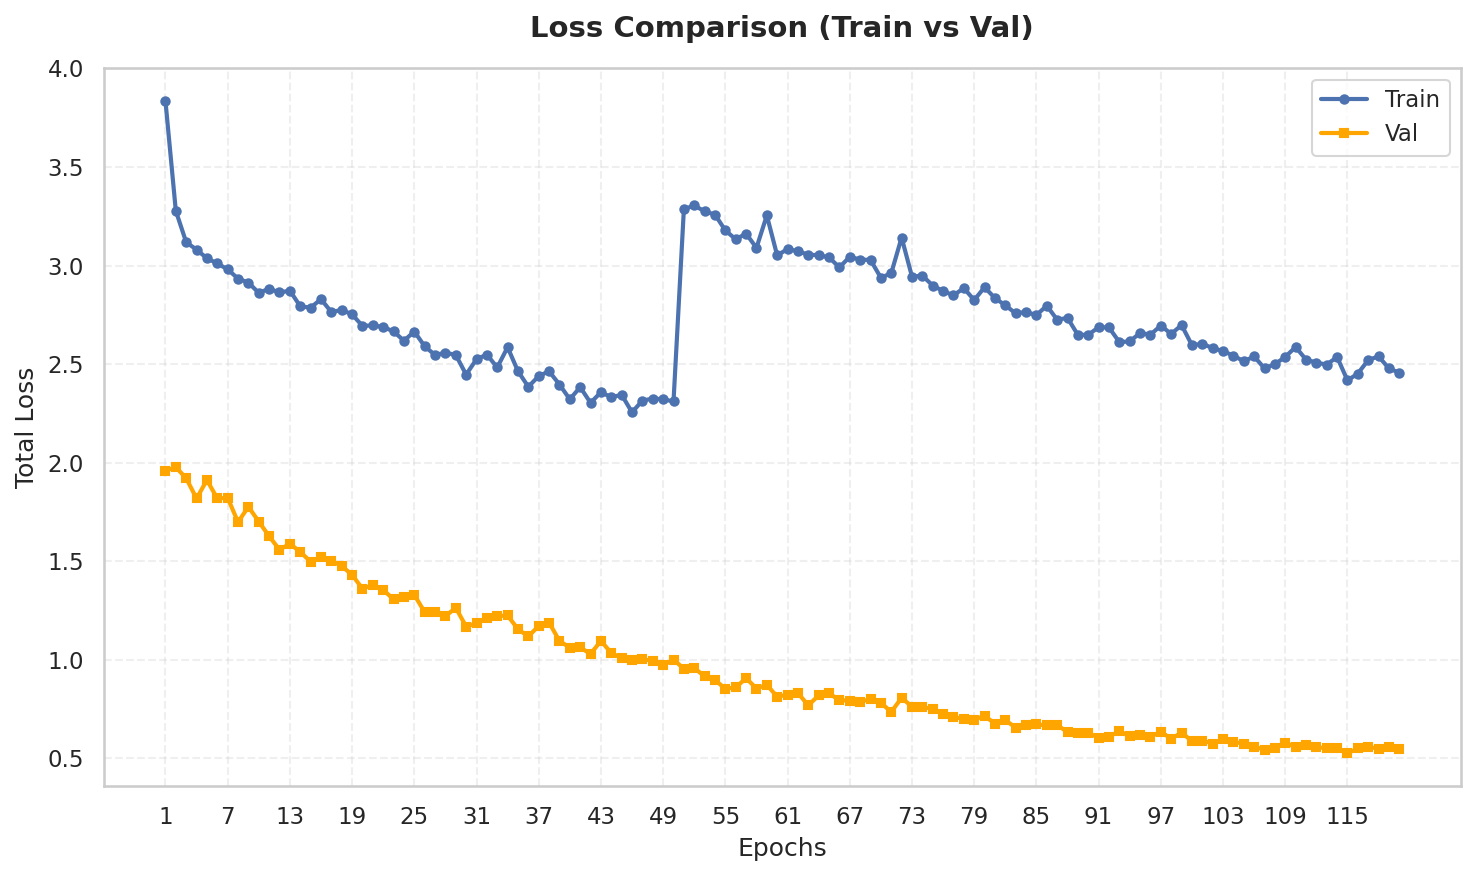

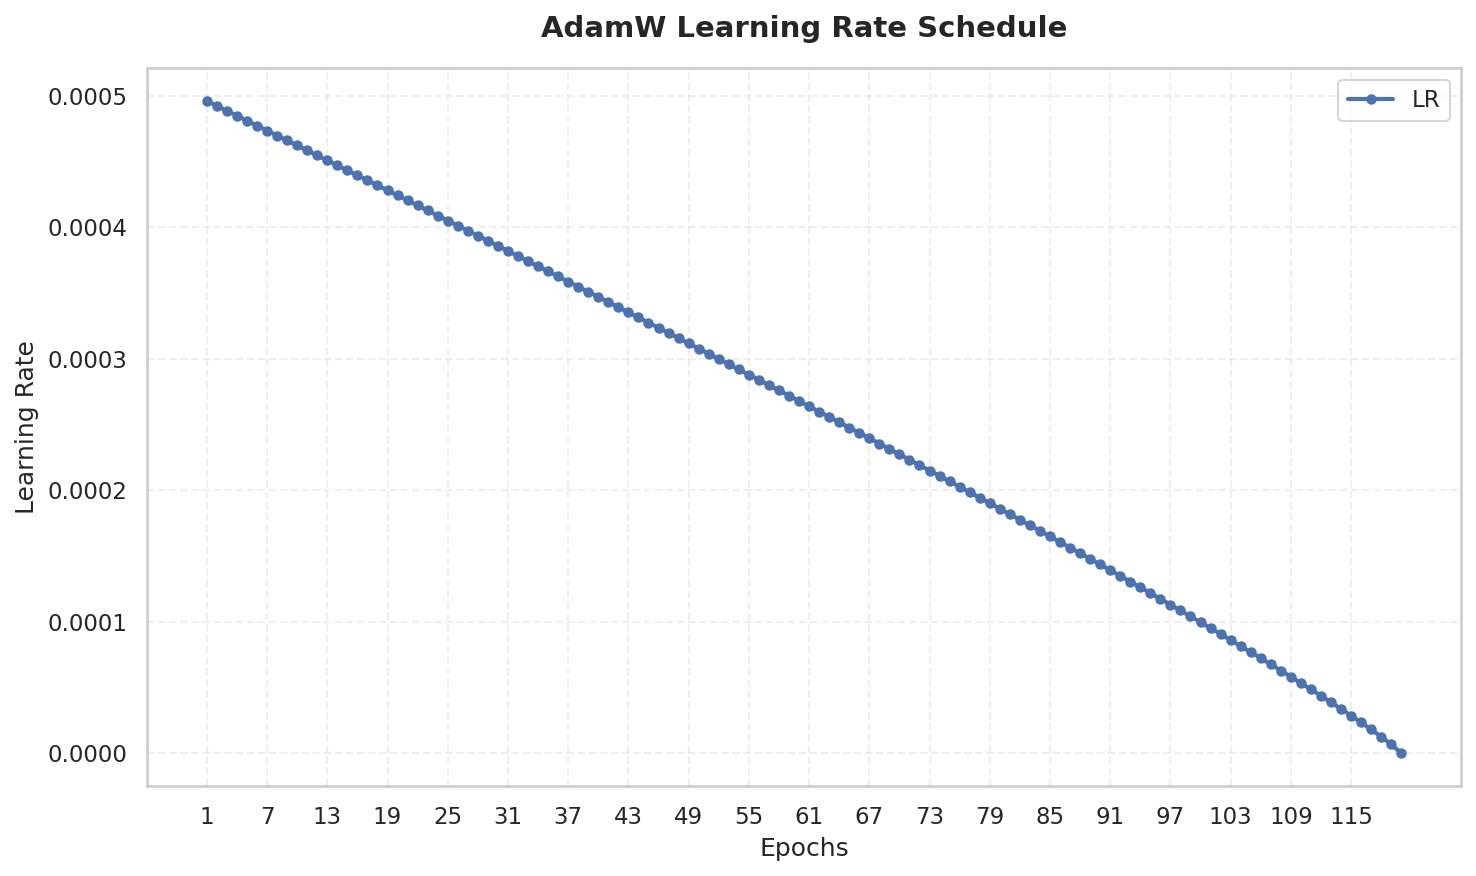

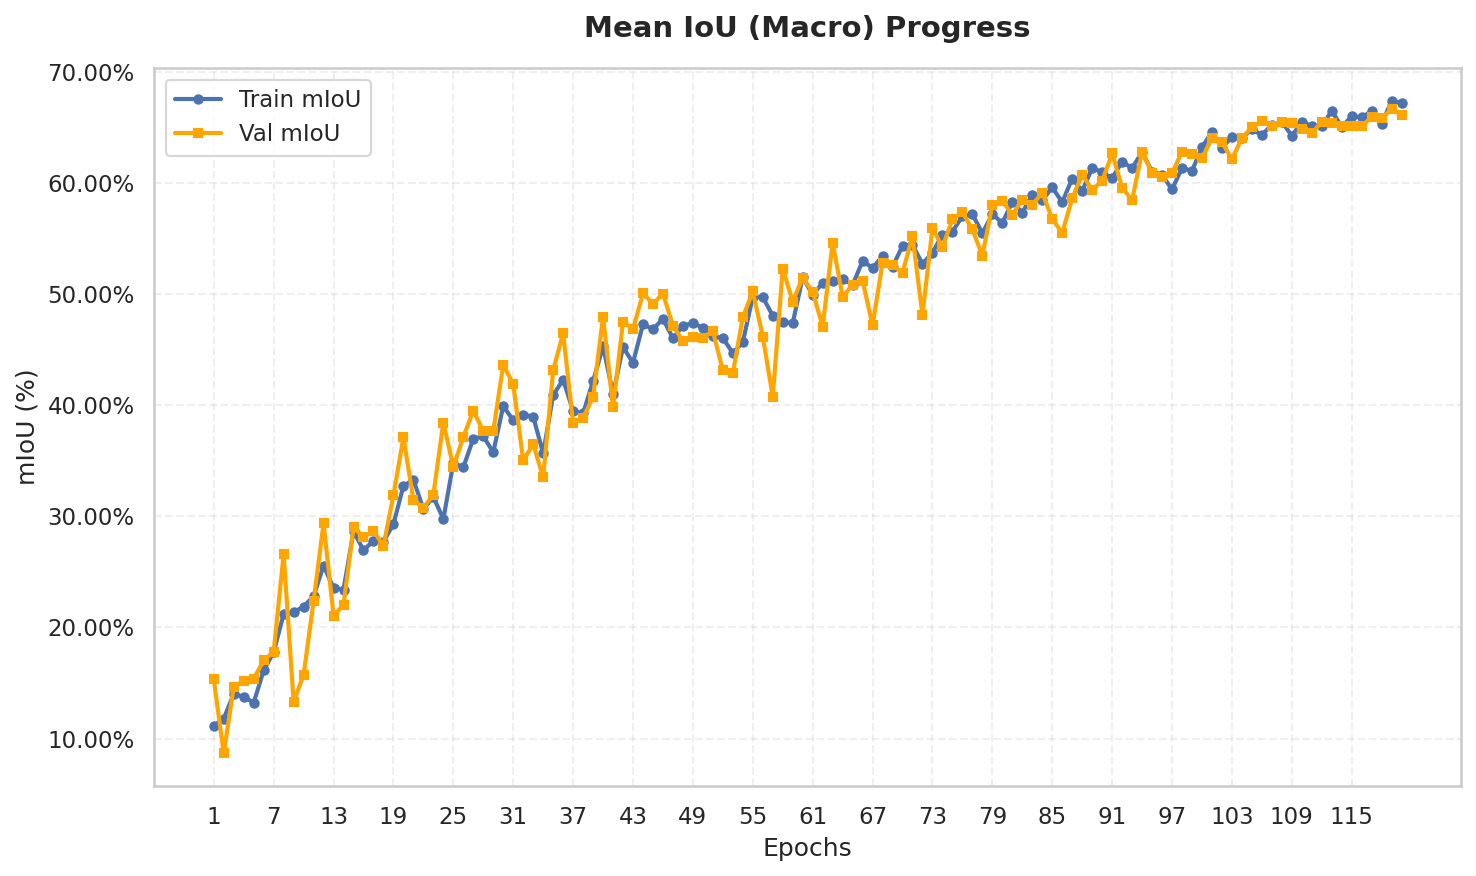

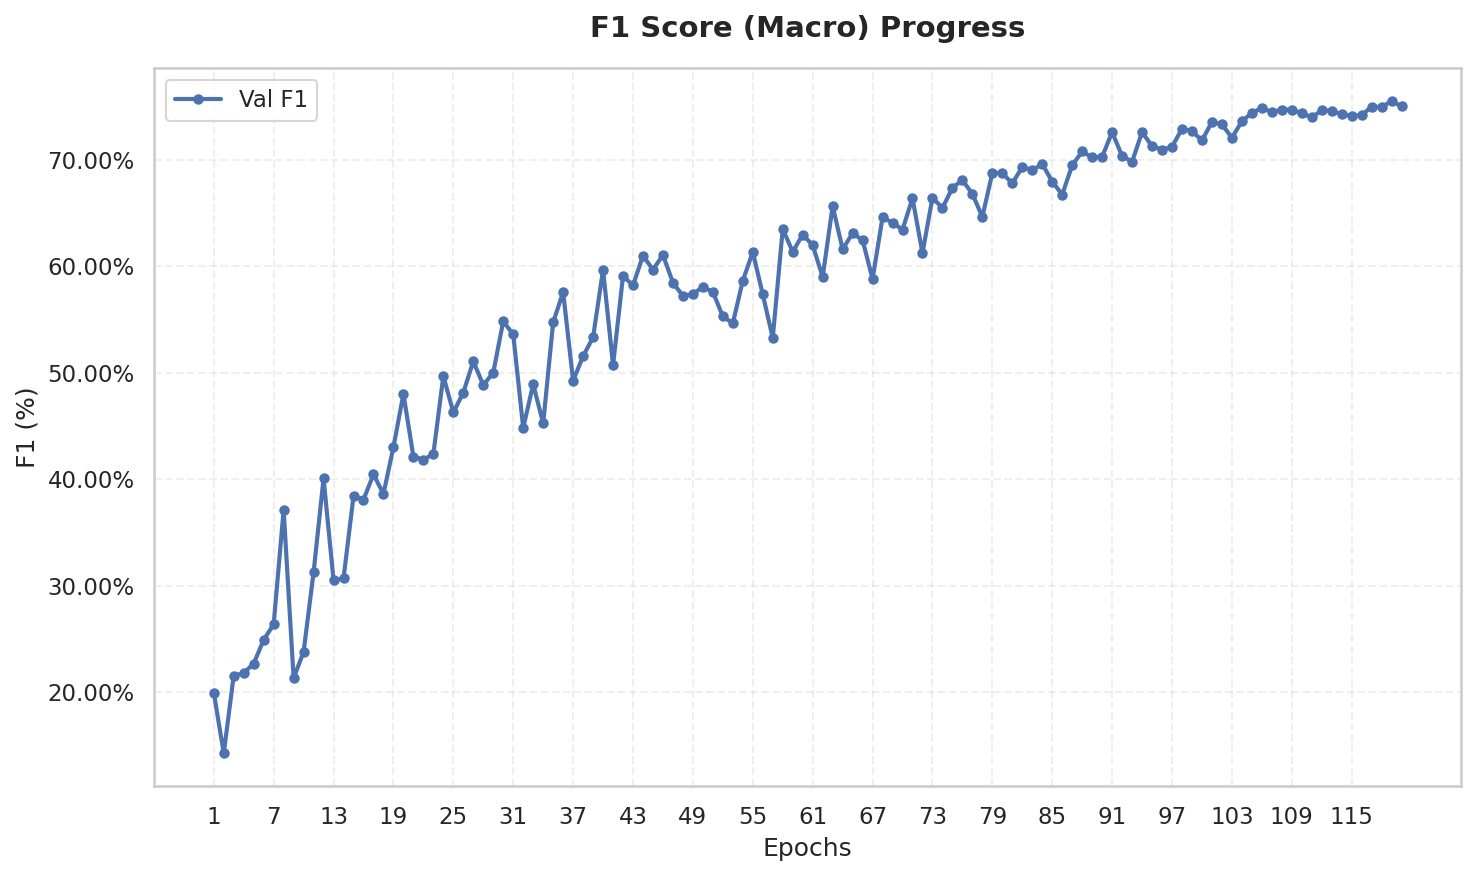

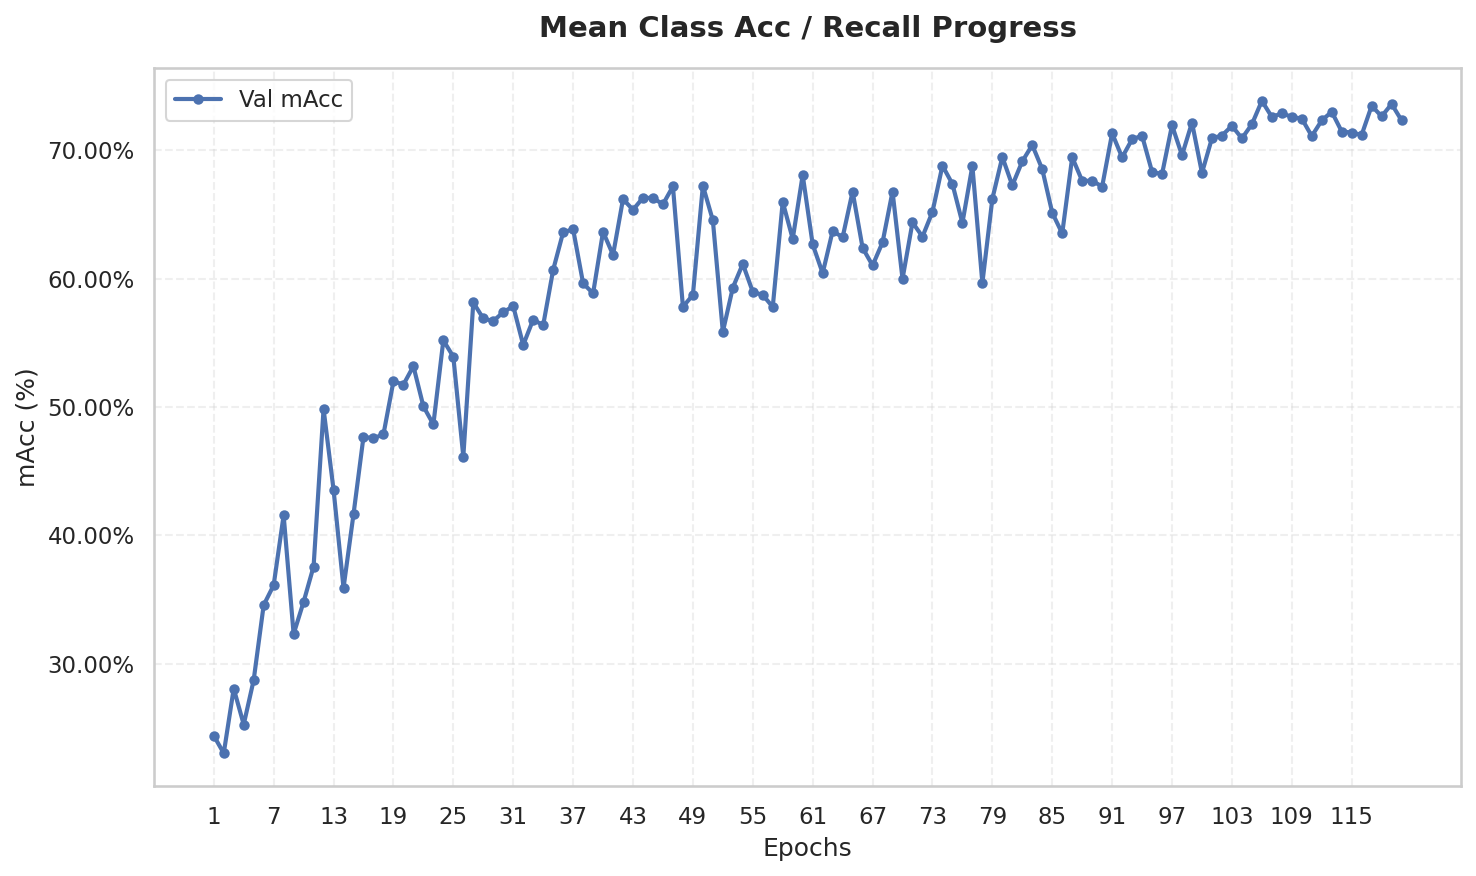

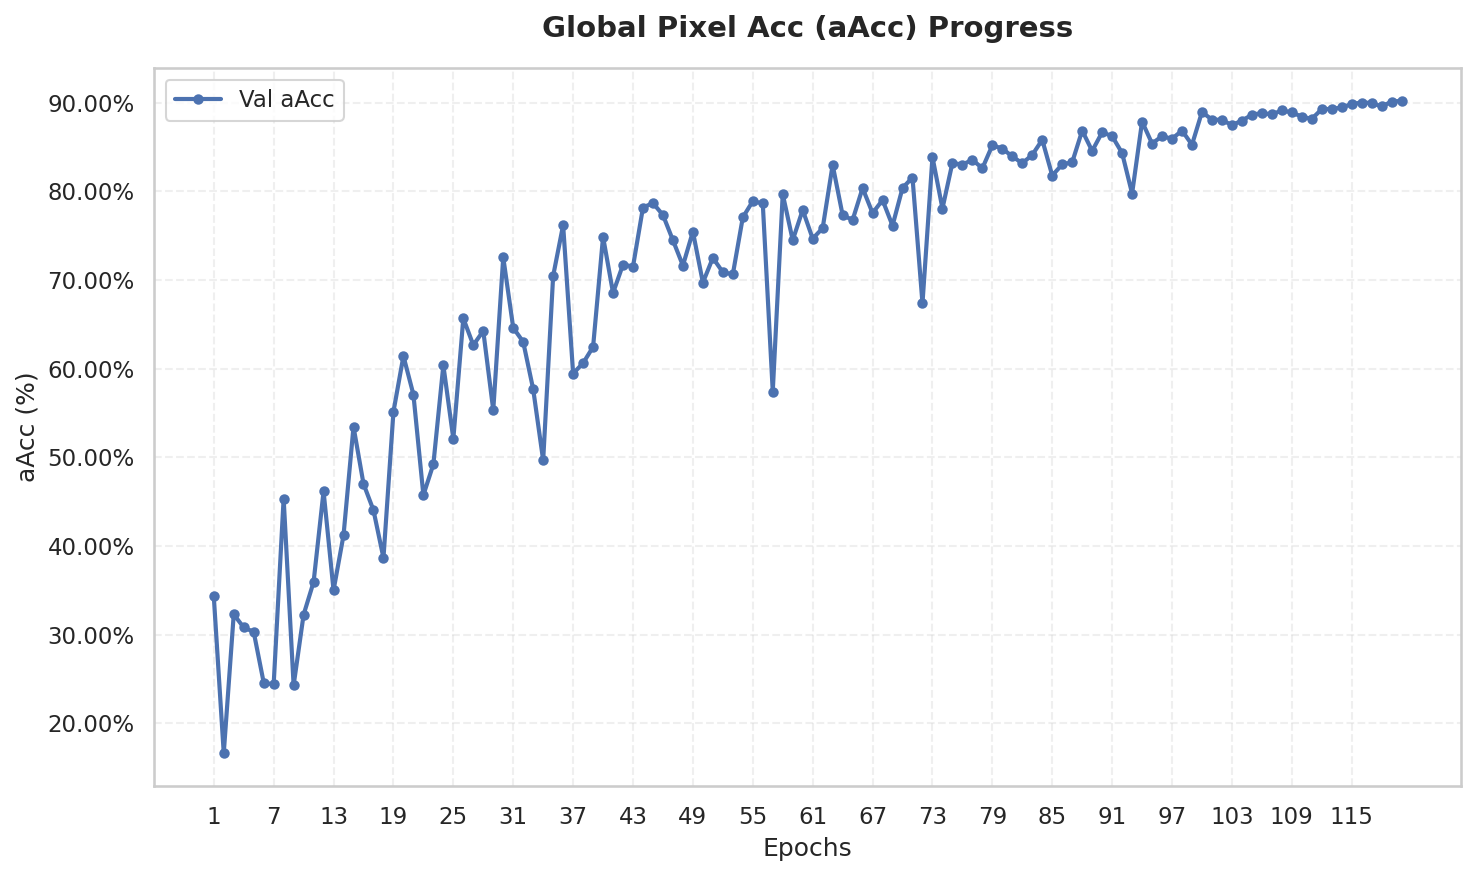

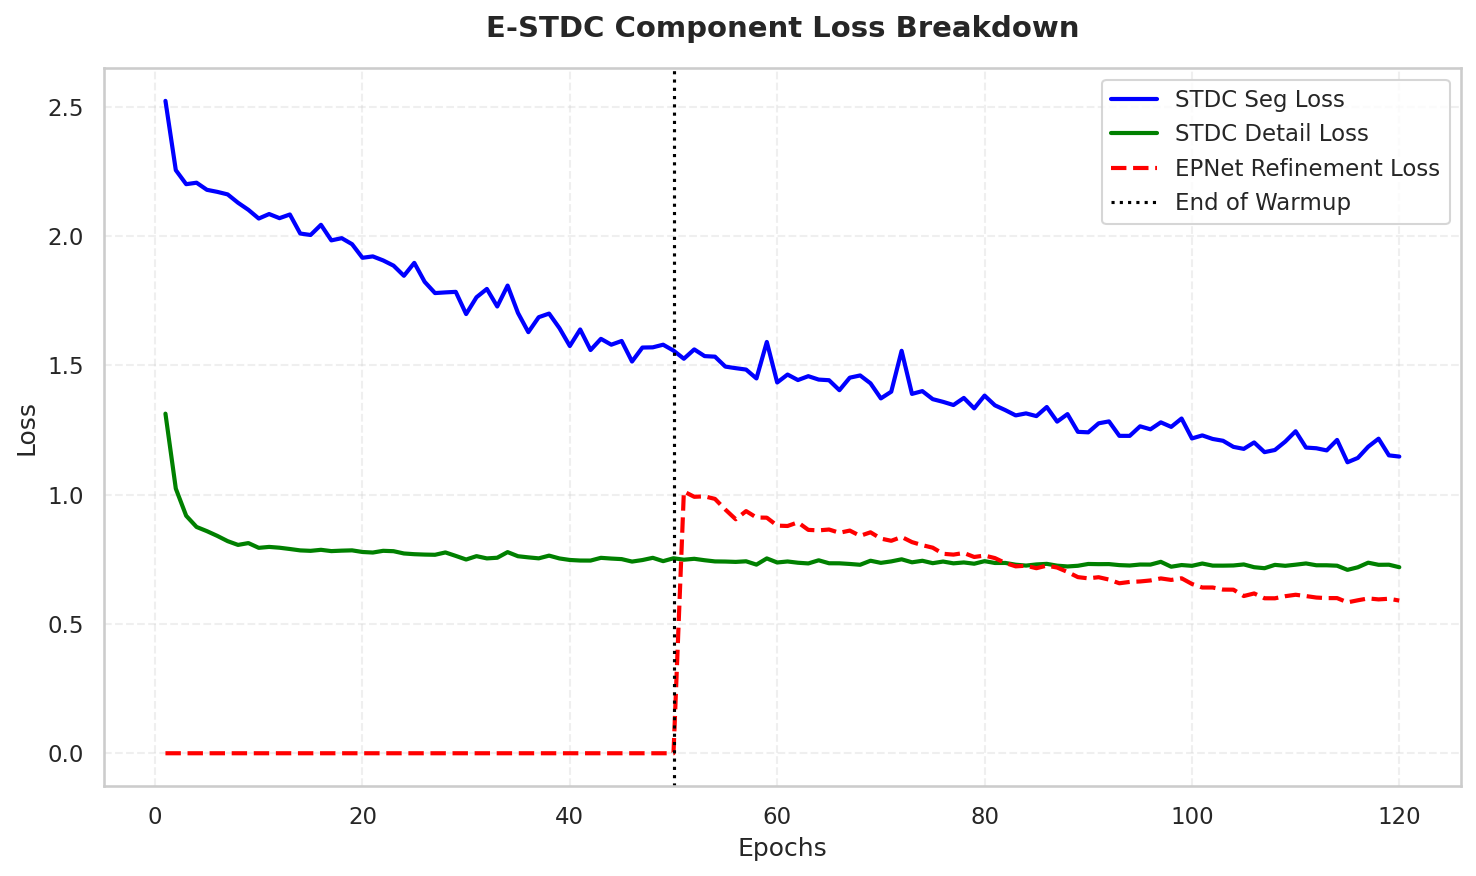

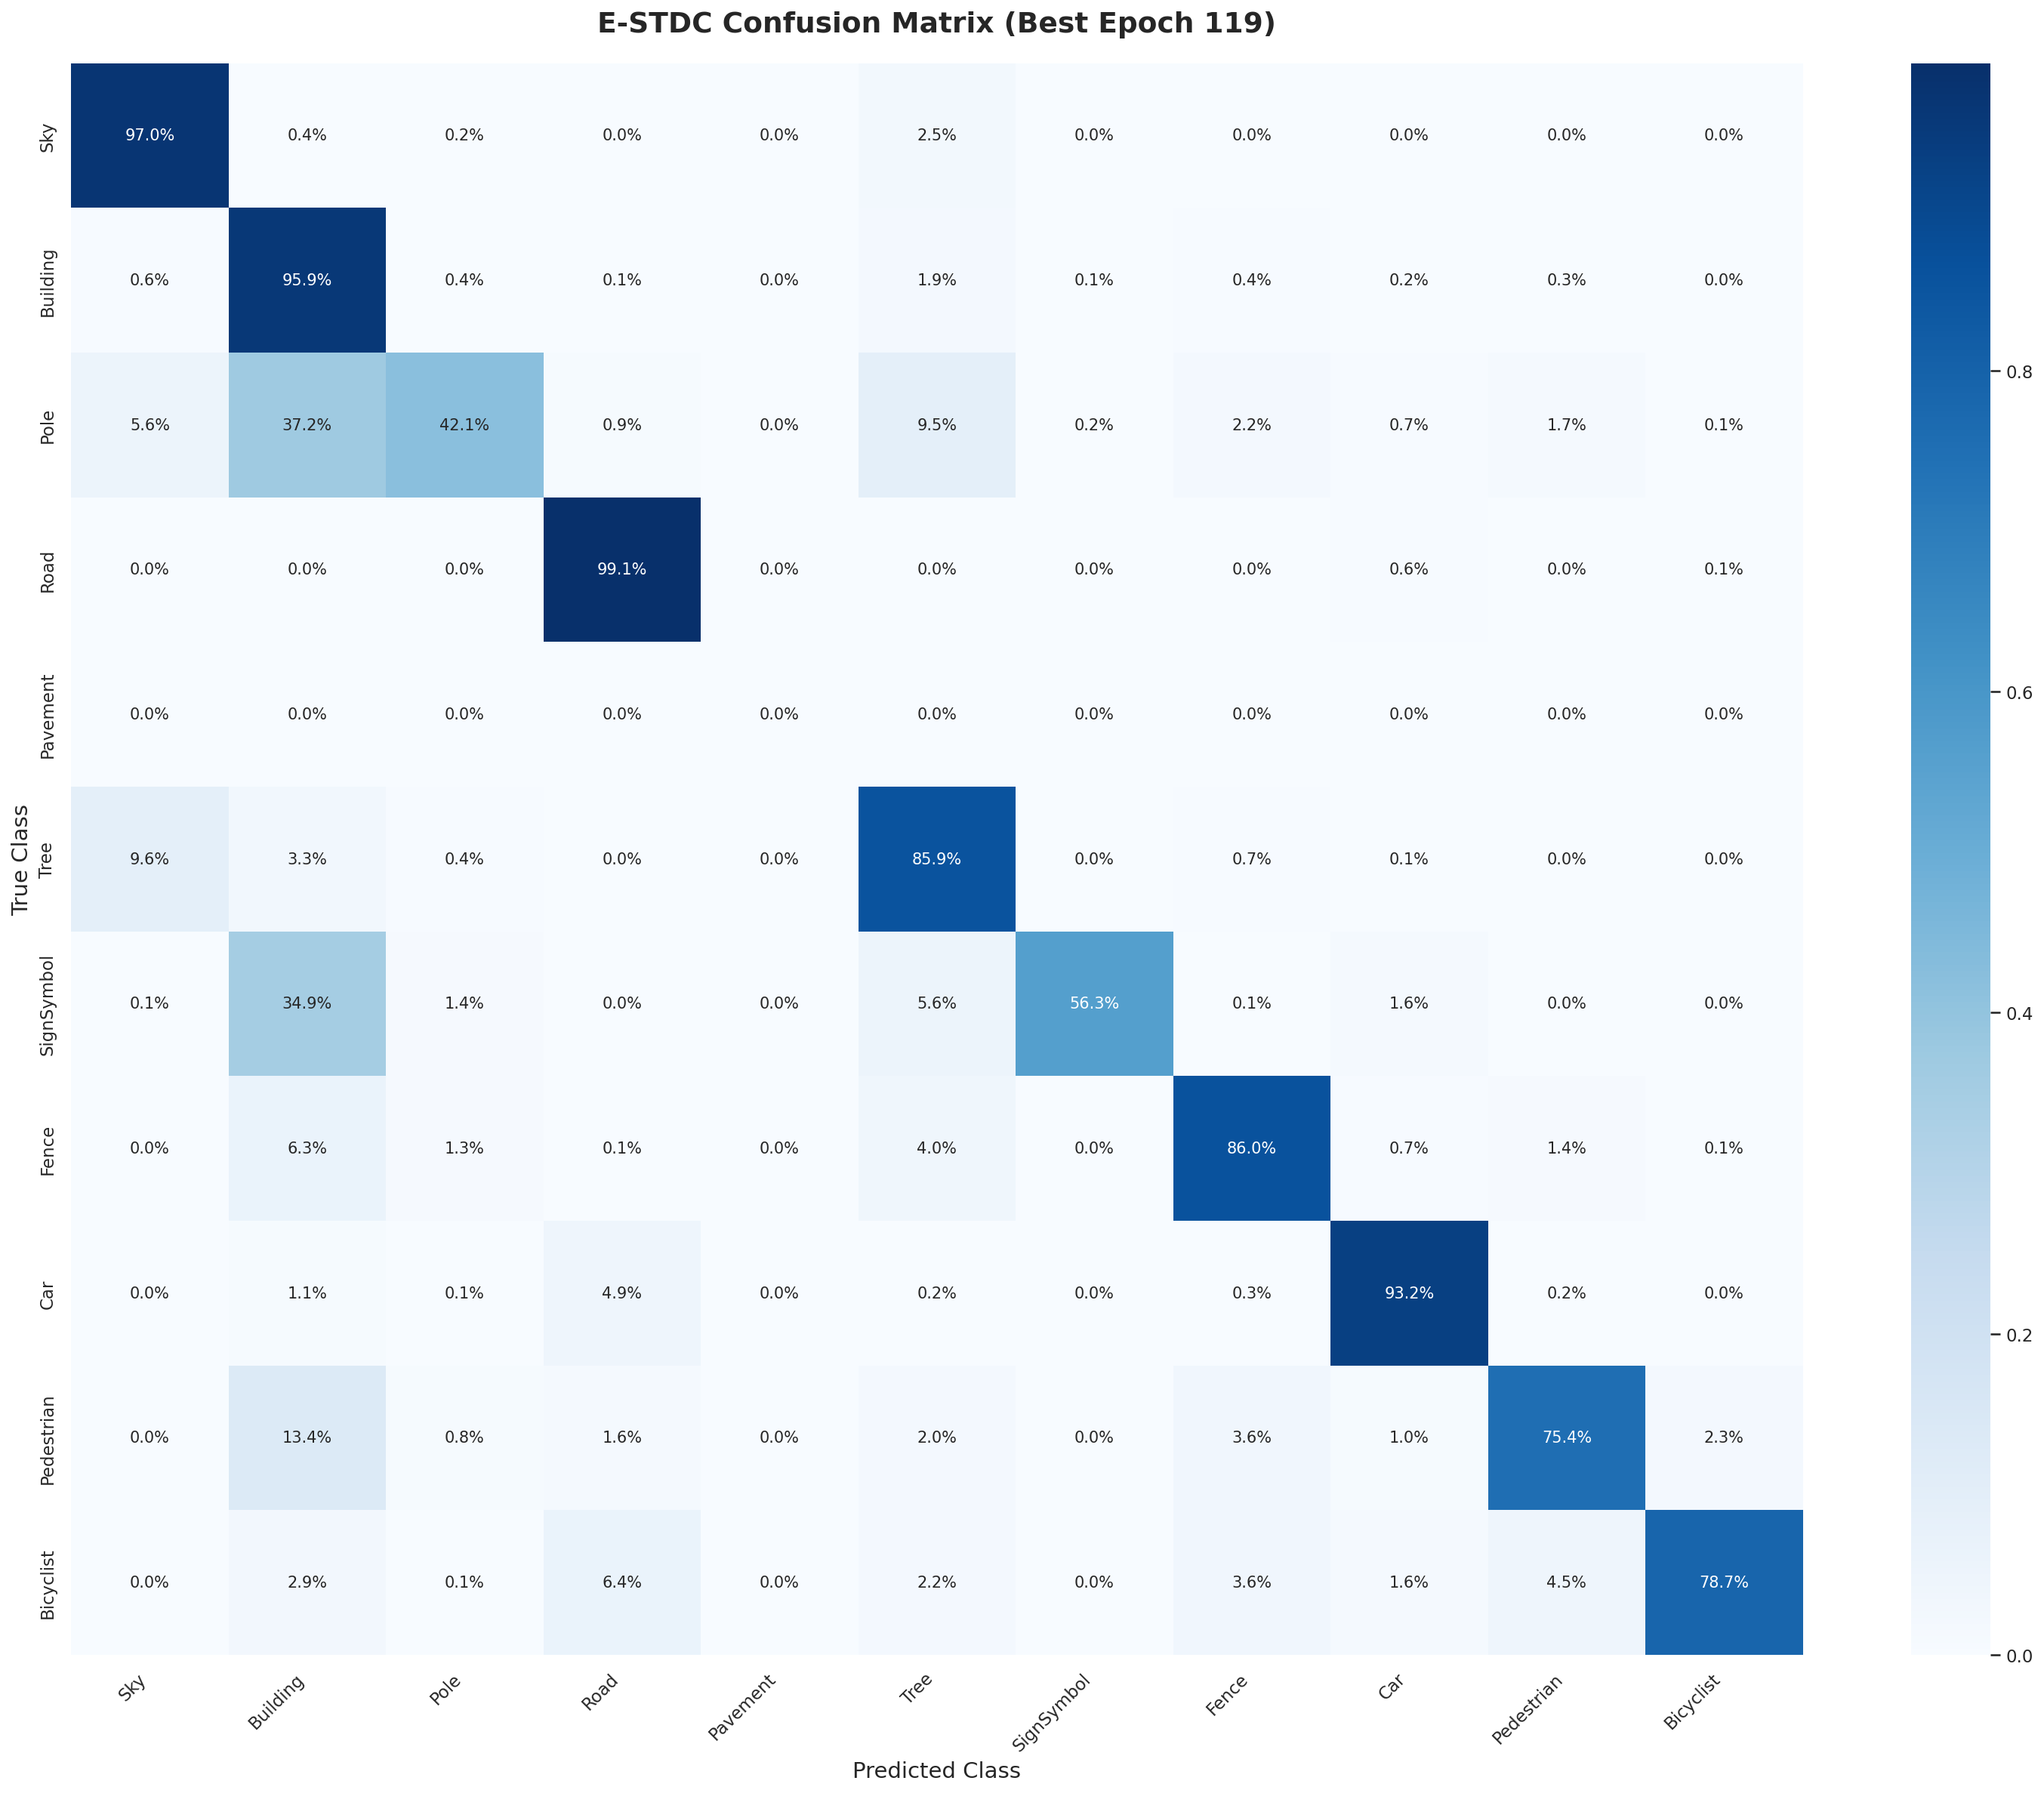


-------------------------------------------------------------------------------------
Architecture: E-STDC (STDC Base + EPNet Postprocessing)
Loss Config: Multi-Loss (Seg + Detail + EPNet) with Two-Stage Warmup
Total Parameters:      6,757,264  (6.76 M)
Trainable Parameters:  6,757,264  (6.76 M)
-------------------------------------------------------------------------------------
SUCCESS: All artifacts and graphs routed to:
/home/hrusikesh-nishank/Pictures/E-stdc_camvid/Results_Export_E-stdc_camvid

FINAL RESULTS (E-STDC Architecture)
Best Validation mIoU (Macro):     66.67% (Epoch 119)
Final Epoch Pixel Acc (aAcc):     90.20%
Final Epoch Mean Class Acc (mAcc):72.33%
Final Epoch F1-Score (Macro):     75.00%
Final Epoch Recall (Macro):       72.33%
Total Training Time:              2:11:01
-------------------------------------------------------------------------------------
CLASS NAME         | IoU (%)      | F1-Score (%)   | Precision (%)  | Recall (%)  
------------------------------

In [10]:
# ============================================================
# STEP 6: EXPORT RESULTS, PLOTS, CONFUSION MATRIX, FINAL SUMMARY
# Target Architecture: E-STDC (STDC Base + EPNet Postprocessing) #[cite: 1, 4]
# Target Dataset: CamVid #[cite: 4, 5]
# Optimized for: Automated Matrix Reconstruction, Class-Wise Parsing, 
# Percentage Matrices, Continuous Metric Plotting, Multi-Loss Visualization
# ============================================================

import os
import json
from pathlib import Path
from datetime import timedelta

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from tqdm import tqdm
import torch.nn.functional as F

# ------------------------------------------------------------
# SAFETY CHECKS & PATH INHERITANCE
# ------------------------------------------------------------
required_globals = [
    "history", "model", "CLASS_NAMES", "CLASSES",
    "CHECKPOINT_DIR", "best_record", "DEVICE"
]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables from previous steps: {missing}")

IGNORE_INDEX = globals().get("IGNORE_INDEX", 255)
FINAL_SAVE_DIR = globals().get("FINAL_SAVE_DIR", Path("/home/hrusikesh-nishank/Pictures/E-stdc_camvid/Results_Export_E-stdc_camvid"))
FINAL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"[*] Final export directory validated: {FINAL_SAVE_DIR.resolve()}\n")

# ------------------------------------------------------------
# AUTOMATED MATRIX RECOVERY PROTOCOL (CRASH PROOF)
# ------------------------------------------------------------
BEST_CONF_MATRIX = globals().get("best_conf_matrix", globals().get("val_conf_matrix", None))

if BEST_CONF_MATRIX is None and "val_loader" in globals() and "model" in globals():
    print("[!] Confusion matrix missing from RAM. Reconstructing from Best Checkpoint...")
    # UPDATED: Pointing to the CamVid checkpoint
    best_ckpt_path = os.path.join(CHECKPOINT_DIR, "best_model_estdc_camvid.pt")
    
    if os.path.exists(best_ckpt_path):
        ckpt = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()
        
        reconstructed_cm = np.zeros((CLASSES, CLASSES), dtype=np.int64)
        
        def _fast_confusion_matrix(y_true, y_pred, num_classes):
            idx = num_classes * y_true + y_pred
            return np.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)
        
        USE_AMP = torch.cuda.is_available()
        pbar = tqdm(val_loader, total=len(val_loader), desc="Reconstructing Metrics (E-STDC)", leave=False)
        
        with torch.no_grad():
            for images, masks in pbar:
                images = images.to(DEVICE, non_blocking=True)
                masks = masks.to(DEVICE, non_blocking=True)
                _, _, val_h, val_w = images.shape
                
                with torch.autocast(device_type="cuda", enabled=USE_AMP):
                    # E-STDC Evaluation Mode (Returns Refined Logits directly via SUIP Propagation) #[cite: 1]
                    logits = model(images)
                    logits_up = F.interpolate(logits, size=(val_h, val_w), mode="bilinear", align_corners=False)
                    
                    if globals().get("USE_FLIP_TTA", False):
                        flip_logits = model(torch.flip(images, dims=[3]))
                        flip_logits_up = F.interpolate(flip_logits, size=(val_h, val_w), mode="bilinear", align_corners=False)
                        logits_up += torch.flip(flip_logits_up, dims=[3])
                        logits_up /= 2.0
                        
                preds = torch.argmax(logits_up, dim=1).cpu().numpy().astype(np.int64)
                targets_np = masks.cpu().numpy().astype(np.int64)
                
                valid = (targets_np != IGNORE_INDEX)
                if valid.any():
                    reconstructed_cm += _fast_confusion_matrix(targets_np[valid], preds[valid], CLASSES)
                    
        BEST_CONF_MATRIX = reconstructed_cm
        print("[*] Reconstruction Complete! Restoring class-wise scores.")
    else:
        print("[!] Could not locate best checkpoint on disk. Class-wise metrics will remain empty.")

# ------------------------------------------------------------
# BUILD MAIN DATAFRAME
# ------------------------------------------------------------
num_epochs = len(history.get("epoch", []))

def get_hist_col(key, fallback_key=None):
    col = history.get(key, [])
    if len(col) == num_epochs: return col
    if fallback_key and len(history.get(fallback_key, [])) == num_epochs: return history[fallback_key]
    if len(col) > 0:
        return col + [np.nan] * (num_epochs - len(col)) if len(col) < num_epochs else col[:num_epochs]
    return [np.nan] * num_epochs

df = pd.DataFrame({
    "Epoch": get_hist_col("epoch"),
    "Train_Total_Loss": get_hist_col("train_total_loss"),
    "Train_Seg_Loss": get_hist_col("train_seg_loss"),       # STDC Main Loss #[cite: 4]
    "Train_Detail_Loss": get_hist_col("train_detail_loss"), # STDC Detail Loss #[cite: 4]
    "Train_EPNet_Loss": get_hist_col("train_epnet_loss"),   # EPNet Refinement Loss #[cite: 1]
    "Train_mIoU": get_hist_col("train_mIoU_Macro", fallback_key="train_miou"),
    "Val_Total_Loss": get_hist_col("val_total_loss"),
    "Val_mIoU": get_hist_col("val_mIoU_Macro", fallback_key="val_miou"),
    "Val_F1_Macro": get_hist_col("val_F1_Macro"),
    "Val_Precision_Macro": get_hist_col("val_Precision_Macro"),
    "Val_Recall_Macro": get_hist_col("val_Recall_Macro", fallback_key="val_macc"),
    "Val_Micro_mIoU": get_hist_col("val_mIoU_Micro", fallback_key="val_aacc"),
    "Learning_Rate": get_hist_col("learning_rate"),
    "Epoch_Time_sec": get_hist_col("epoch_time_sec"),
})

total_training_time_sec = float(df["Epoch_Time_sec"].sum()) if not df["Epoch_Time_sec"].isna().all() else 0.0
total_time_str = str(timedelta(seconds=int(total_training_time_sec)))
df["Total_Training_Session_Time"] = total_time_str

# ------------------------------------------------------------
# PREPARE EXHAUSTIVE CLASS-WISE DATA
# ------------------------------------------------------------
class_wise_data = []
if BEST_CONF_MATRIX is not None:
    tp = np.diag(BEST_CONF_MATRIX)
    fp = BEST_CONF_MATRIX.sum(axis=0) - tp
    fn = BEST_CONF_MATRIX.sum(axis=1) - tp
    
    iou_per_class = tp / np.maximum(tp + fp + fn, 1)
    precision_per_class = tp / np.maximum(tp + fp, 1)
    recall_per_class = tp / np.maximum(tp + fn, 1)
    f1_per_class = 2 * (precision_per_class * recall_per_class) / np.maximum(precision_per_class + recall_per_class, 1e-10)
    
    for i, name in enumerate(CLASS_NAMES):
        class_wise_data.append({
            "Class Name": name,
            "IoU (%)": float(iou_per_class[i] * 100),
            "F1-Score (%)": float(f1_per_class[i] * 100),
            "Precision (%)": float(precision_per_class[i] * 100),
            "Recall (%)": float(recall_per_class[i] * 100)
        })

# ------------------------------------------------------------
# EXPORT FINAL RESULTS CSV & EXCEL
# ------------------------------------------------------------
def safe_pct(val):
    if pd.isna(val) or np.isnan(val): return 0.0
    return val if val > 1.0 else val * 100.0

final_micro_miou = safe_pct(df["Val_Micro_mIoU"].iloc[-1]) 
final_mIoU = safe_pct(df["Val_mIoU"].iloc[-1])
final_mRecall = safe_pct(df["Val_Recall_Macro"].iloc[-1])  
final_mF1 = safe_pct(df["Val_F1_Macro"].iloc[-1])

best_miou = safe_pct(best_record.get("best_miou", 0.0))
best_epoch = best_record.get("best_epoch", -1)

final_global_data = [
    {"Metric": "Best Validation mIoU (Macro)", "Value": f"{best_miou:.2f}%"},
    {"Metric": "Global Pixel Accuracy (aAcc)", "Value": f"{final_micro_miou:.2f}%"},
    {"Metric": "Final Epoch Mean Class Acc (mAcc)", "Value": f"{final_mRecall:.2f}%"},
    {"Metric": "Final Epoch Mean Recall (Macro)", "Value": f"{final_mRecall:.2f}%"},
    {"Metric": "Final Epoch Mean F1 Score (Macro)", "Value": f"{final_mF1:.2f}%"},
    {"Metric": "Total Training Time", "Value": total_time_str}
]
# UPDATED: Export filenames for CamVid
pd.DataFrame(final_global_data).to_csv(FINAL_SAVE_DIR / "finalresults_estdc_camvid.csv", index=False)

excel_path = FINAL_SAVE_DIR / "Training_Metrics_Report_ESTDC_CamVid.xlsx"
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Epoch_Metrics', index=False)
    if class_wise_data:
        pd.DataFrame(class_wise_data).to_excel(writer, sheet_name='Class_Wise_Results', index=False)

# ------------------------------------------------------------
# STANDARD SEPARATE PLOTS (INDIVIDUAL METRICS)
# ------------------------------------------------------------
sns.set_style("whitegrid")

def save_separate_plot(filename, title, ylabel, train_data, val_data=None, label1="Train", label2="Val", is_percentage=False):
    plt.figure(figsize=(10, 6))
    
    epochs_range = df["Epoch"].dropna().values if not df["Epoch"].isna().all() else np.arange(1, len(train_data) + 1)
    train_clean = np.array(train_data, dtype=float)
    
    if not np.isnan(train_clean).all():
        plt.plot(epochs_range, train_clean, label=label1, lw=2, marker='o', markersize=4)
    
    if val_data is not None:
        val_clean = np.array(val_data, dtype=float)
        if not np.isnan(val_clean).all():
            plt.plot(epochs_range, val_clean, label=label2, lw=2, marker='s', markersize=4, color='orange')
            
    if is_percentage:
        plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

    if len(epochs_range) > 0:
        plt.xticks(np.arange(min(epochs_range), max(epochs_range) + 1, step=max(1, len(epochs_range)//20)))

    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / f"{filename}.png", dpi=600, bbox_inches='tight')
    plt.show() 
    plt.close()

# Extract Data
train_loss = df["Train_Total_Loss"].tolist()
val_loss = df["Val_Total_Loss"].tolist()
train_miou = df["Train_mIoU"].tolist()
val_miou = df["Val_mIoU"].tolist()
val_f1 = df["Val_F1_Macro"].tolist()
val_recall = df["Val_Recall_Macro"].tolist()
val_micro = df["Val_Micro_mIoU"].tolist()
learning_rate = df["Learning_Rate"].tolist()

# 1. Standard Plots
save_separate_plot("loss_comparison", "Loss Comparison (Train vs Val)", "Total Loss", train_loss, val_loss)
save_separate_plot("learning_rate_progress", "AdamW Learning Rate Schedule", "Learning Rate", learning_rate, label1="LR")
save_separate_plot("miou_progress", "Mean IoU (Macro) Progress", "mIoU (%)", train_miou, val_miou, label1="Train mIoU", label2="Val mIoU", is_percentage=True)
save_separate_plot("f1_progress", "F1 Score (Macro) Progress", "F1 (%)", val_f1, label1="Val F1", is_percentage=True)
save_separate_plot("recall_progress", "Mean Class Acc / Recall Progress", "mAcc (%)", val_recall, label1="Val mAcc", is_percentage=True)
save_separate_plot("micro_miou_progress", "Global Pixel Acc (aAcc) Progress", "aAcc (%)", val_micro, label1="Val aAcc", is_percentage=True)

# 2. Specialized Plot: E-STDC Component Loss Breakdown
plt.figure(figsize=(10, 6))
epochs_range = df["Epoch"].dropna().values if not df["Epoch"].isna().all() else np.arange(1, len(train_loss) + 1)
plt.plot(epochs_range, df["Train_Seg_Loss"], label="STDC Seg Loss", lw=2, color='blue')
plt.plot(epochs_range, df["Train_Detail_Loss"], label="STDC Detail Loss", lw=2, color='green')
plt.plot(epochs_range, df["Train_EPNet_Loss"], label="EPNet Refinement Loss", lw=2, color='red', linestyle='--')
plt.axvline(x=globals().get("WARMUP_EPOCHS", 50), color='black', linestyle=':', label='End of Warmup')
plt.title("E-STDC Component Loss Breakdown", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(FINAL_SAVE_DIR / "estdc_loss_breakdown.png", dpi=600, bbox_inches='tight')
plt.show()
plt.close()

# ------------------------------------------------------------
# PERCENTAGE-BASED CONFUSION MATRIX
# ------------------------------------------------------------
if BEST_CONF_MATRIX is not None:
    plt.figure(figsize=(20, 16)) 
    
    cm_normalized = BEST_CONF_MATRIX.astype('float') / (BEST_CONF_MATRIX.sum(axis=1)[:, np.newaxis] + 1e-10)
    
    sns.heatmap(
        cm_normalized, annot=True, fmt='.1%', cmap='Blues', 
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, 
        annot_kws={"size": 10}
    ) 
    
    plt.title(f"E-STDC Confusion Matrix (Best Epoch {best_epoch})", fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('True Class', fontsize=14)
    plt.xlabel('Predicted Class', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / "confusion_matrix_percentages.png", dpi=600, bbox_inches='tight')
    plt.show() 
    plt.close()

# ------------------------------------------------------------
# FINAL PRINT SUMMARY
# ------------------------------------------------------------
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n" + "-"*85)
print(f"Architecture: E-STDC (STDC Base + EPNet Postprocessing)") #[cite: 1, 4]
print(f"Loss Config: Multi-Loss (Seg + Detail + EPNet) with Two-Stage Warmup") #[cite: 1, 4]
print(f"Total Parameters:      {total_params:,}  ({total_params/1e6:.2f} M)")
print(f"Trainable Parameters:  {trainable_params:,}  ({trainable_params/1e6:.2f} M)")
print(f"-"*85)
print(f"SUCCESS: All artifacts and graphs routed to:\n{FINAL_SAVE_DIR.resolve()}")
print("\n" + "="*85)
print(f"FINAL RESULTS (E-STDC Architecture)")
print("="*85)
print(f"Best Validation mIoU (Macro):     {best_miou:.2f}% (Epoch {best_epoch})")
print(f"Final Epoch Pixel Acc (aAcc):     {final_micro_miou:.2f}%")
print(f"Final Epoch Mean Class Acc (mAcc):{final_mRecall:.2f}%")
print(f"Final Epoch F1-Score (Macro):     {final_mF1:.2f}%")
print(f"Final Epoch Recall (Macro):       {final_mRecall:.2f}%")
print(f"Total Training Time:              {total_time_str}")
print("-" * 85)
print(f"{'CLASS NAME':<18} | {'IoU (%)':<12} | {'F1-Score (%)':<14} | {'Precision (%)':<14} | {'Recall (%)':<12}")
print("-" * 85)

if class_wise_data:
    for item in class_wise_data:
        print(f"{item['Class Name']:<18} | {item['IoU (%)']:<12.2f} | {item['F1-Score (%)']:<14.2f} | {item['Precision (%)']:<14.2f} | {item['Recall (%)']:<12.2f}")

[*] Filtered Multi-Metric Graph saved successfully to: /home/hrusikesh-nishank/Pictures/E-stdc_camvid/Results_Export_E-stdc_camvid/presentation_combined_metrics_progress_estdc_camvid.png


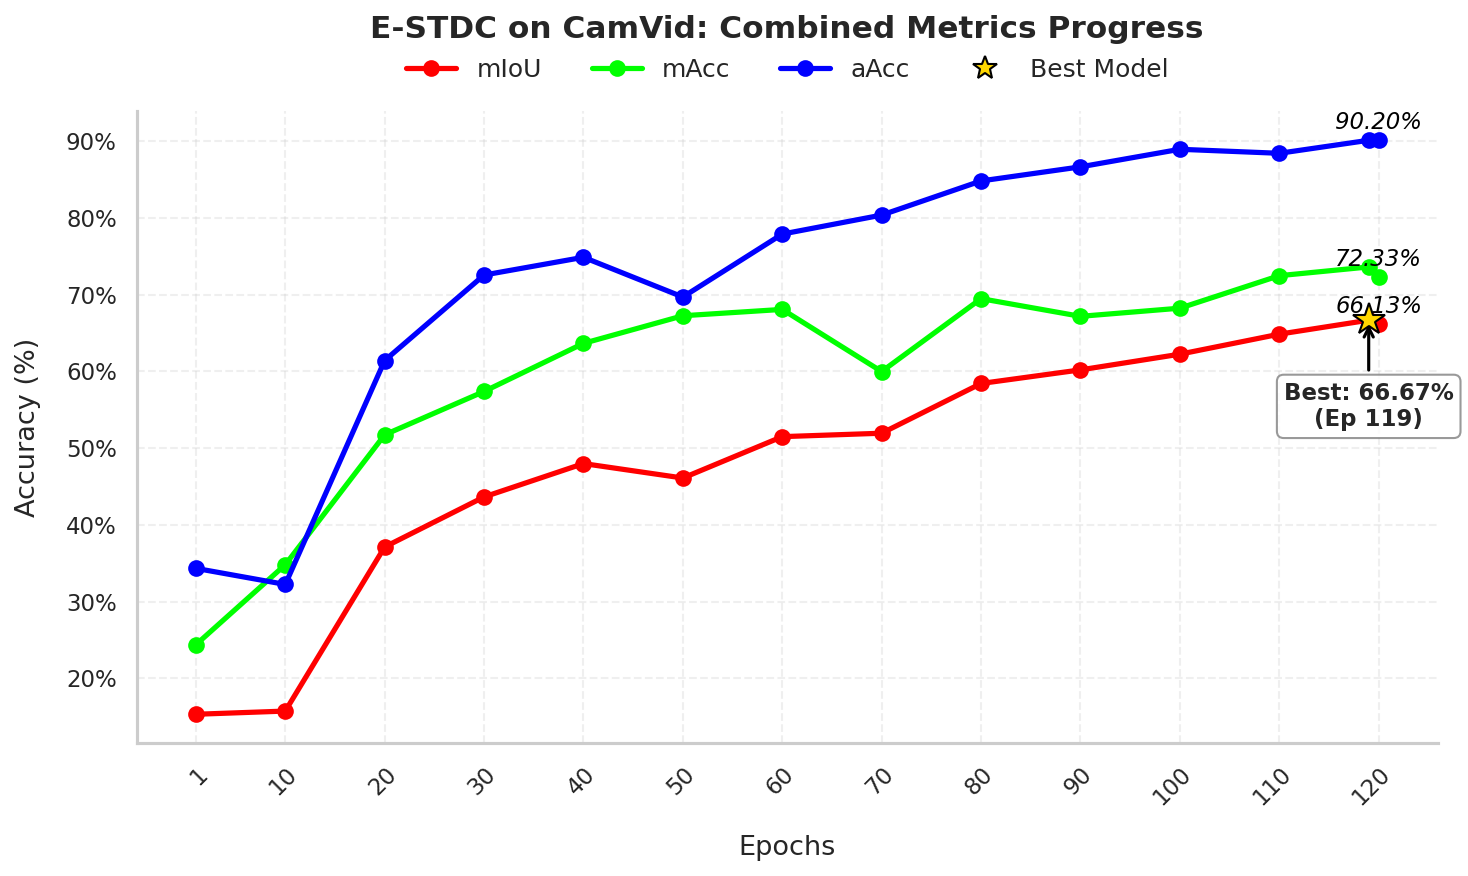

[*] Filtered PolyLR Graph saved successfully to: /home/hrusikesh-nishank/Pictures/E-stdc_camvid/Results_Export_E-stdc_camvid/presentation_learning_rate_schedule_estdc_camvid.png


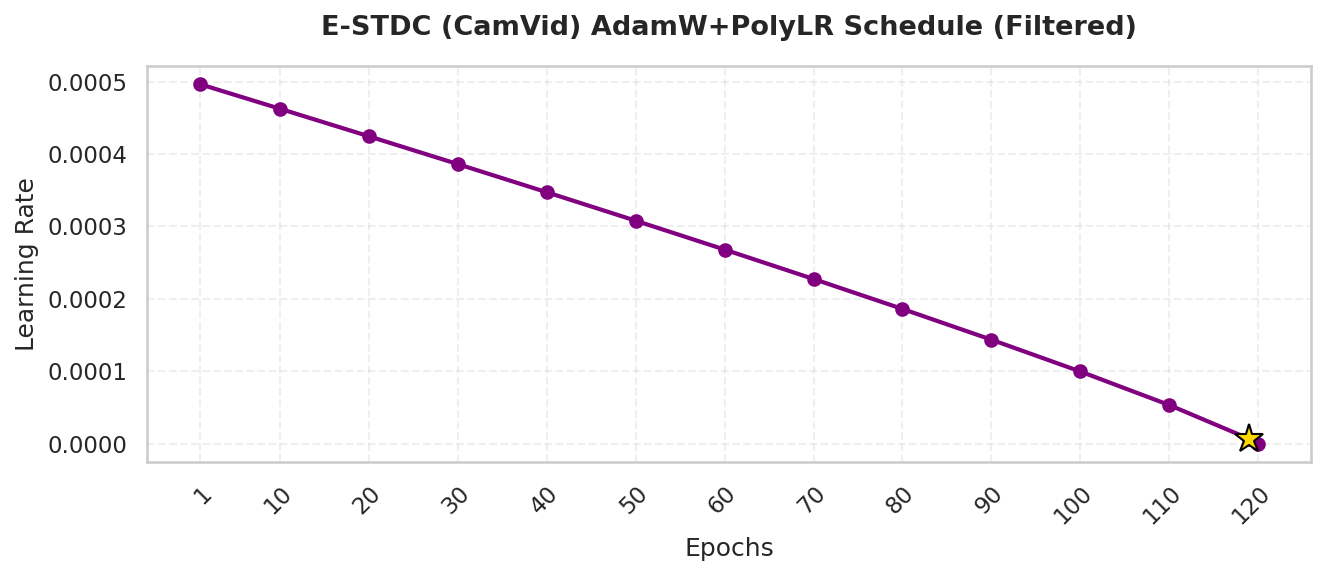

In [11]:
# ============================================================
# STEP 7: FILTERED COMBINED METRICS PLOT & LEARNING RATE
# Target Architecture: E-STDC (STDC Base + EPNet Postprocessing)
# Target Dataset: CamVid 
# Optimized for: Clean X-Axis, Fixed Legend Overlap
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ---------------------------------------------------------------------
# 0) Safety checks
# ---------------------------------------------------------------------
assert "val_miou" in history and len(history["val_miou"]) > 0, "history['val_miou'] is empty."
assert FINAL_SAVE_DIR.exists(), "FINAL_SAVE_DIR does not exist. Run Step 6 directory setup first."

# ---------------------------------------------------------------------
# 1) Setup Plotting Data vs Axis Ticks
# ---------------------------------------------------------------------
best_miou_raw = max(history["val_miou"])
best_miou_idx = history["val_miou"].index(best_miou_raw)
best_epoch = history["epoch"][best_miou_idx]

# Values are already 0-100 scaled from Step 5.
best_miou_pct = best_miou_raw 

all_epochs = list(range(1, len(history["val_miou"]) + 1))
step = 20 if len(all_epochs) > 150 else 10

# List A: STRICTLY for the X-Axis labels (Clean sequence)
tick_epochs = [e for e in all_epochs if (e == 1) or (e % step == 0)]
if all_epochs[-1] not in tick_epochs:
    tick_epochs.append(all_epochs[-1])
tick_epochs = sorted(list(set(tick_epochs)))

# List B: For plotting the actual lines (Includes the peak epoch to connect the dot)
plot_epochs = tick_epochs.copy()
if best_epoch not in plot_epochs:
    plot_epochs.append(best_epoch)
plot_epochs = sorted(list(set(plot_epochs)))

# Extract metrics using the plot_epochs so the data aligns mathematically
indices = [e - 1 for e in plot_epochs]

miou_scores = [history["val_miou"][i] for i in indices]
macc_scores = [history["val_macc"][i] for i in indices]  
aacc_scores = [history["val_aacc"][i] for i in indices]  

# ---------------------------------------------------------------------
# 2) Plot combined metrics
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6)) # Slightly widened for a cleaner look

ax.plot(plot_epochs, miou_scores, marker="o", color='red', linewidth=2.5, label="mIoU", markersize=7)
ax.plot(plot_epochs, macc_scores, marker="o", color='lime', linewidth=2.5, label="mAcc", markersize=7)
ax.plot(plot_epochs, aacc_scores, marker="o", color='blue', linewidth=2.5, label="aAcc", markersize=7)

# Highlight the Best mIoU Point
ax.plot(best_epoch, best_miou_pct, marker="*", color="gold", markersize=16, markeredgecolor="black", zorder=5)

ax.annotate(
    f"Best: {best_miou_pct:.2f}%\n(Ep {best_epoch})", 
    xy=(best_epoch, best_miou_pct), 
    xytext=(best_epoch, best_miou_pct - 8.0), 
    ha="center", va="top", 
    fontsize=11, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5, connectionstyle="arc3")
)

ax.set_xlabel("Epochs", fontsize=13, labelpad=12)
ax.set_ylabel("Accuracy (%)", fontsize=13, labelpad=12)

# UPDATED: Title explicitly reflects E-STDC and CamVid
ax.set_title("E-STDC on CamVid: Combined Metrics Progress", fontsize=15, fontweight='bold', pad=35)

# Apply the tick_epochs to keep the axis beautifully clean
ax.set_xticks(tick_epochs)
ax.set_xticklabels([str(e) for e in tick_epochs]) 
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Add percentage values to the final dots
final_x = plot_epochs[-1]
offset = 0.8

ax.text(final_x, miou_scores[-1] + offset, f"{miou_scores[-1]:.2f}%",
        ha="center", va="bottom", fontsize=11, fontstyle="italic", color="black")
ax.text(final_x, macc_scores[-1] + offset, f"{macc_scores[-1]:.2f}%",
        ha="center", va="bottom", fontsize=11, fontstyle="italic", color="black")
ax.text(final_x, aacc_scores[-1] + offset, f"{aacc_scores[-1]:.2f}%",
        ha="center", va="bottom", fontsize=11, fontstyle="italic", color="black")

import matplotlib.lines as mlines
star_legend = mlines.Line2D([], [], color='white', marker='*', markerfacecolor='gold', markeredgecolor='black', markersize=12, label='Best Model')
handles, labels = ax.get_legend_handles_labels()
handles.append(star_legend)

# Adjusted bbox_to_anchor to push the legend cleanly above the plot but below the title
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.12), ncol=4, frameon=False, fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()

# UPDATED: Filename uniquely tags CamVid and E-STDC
combined_graph_path = FINAL_SAVE_DIR / "presentation_combined_metrics_progress_estdc_camvid.png"
plt.savefig(combined_graph_path, dpi=600, bbox_inches="tight")
print(f"[*] Filtered Multi-Metric Graph saved successfully to: {combined_graph_path}")
plt.show()
plt.close()

# ---------------------------------------------------------------------
# 3) Filtered LR plot at the same epochs 
# ---------------------------------------------------------------------
if "learning_rate" in history and len(history["learning_rate"]) > 0:
    lr_points = [history["learning_rate"][i] for i in indices]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(plot_epochs, lr_points, marker="o", linewidth=2.0, color='purple')
    
    best_lr = history["learning_rate"][best_miou_idx]
    ax.plot(best_epoch, best_lr, marker="*", color="gold", markersize=14, markeredgecolor="black", zorder=5)
    
    ax.set_xlabel("Epochs", fontsize=12)
    ax.set_ylabel("Learning Rate", fontsize=12)
    
    ax.set_xticks(tick_epochs)
    ax.set_xticklabels([str(e) for e in tick_epochs]) 
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    ax.grid(True, linestyle="--", alpha=0.3)
    # UPDATED: Title explicitly reflects E-STDC, CamVid, and AdamW + PolyLR schedule 
    ax.set_title("E-STDC (CamVid) AdamW+PolyLR Schedule (Filtered)", fontsize=13, fontweight='bold', pad=15)

    plt.tight_layout()
    # UPDATED: Filename uniquely tags CamVid and E-STDC
    lr_filtered_path = FINAL_SAVE_DIR / "presentation_learning_rate_schedule_estdc_camvid.png"
    plt.savefig(lr_filtered_path, dpi=600, bbox_inches="tight")
    print(f"[*] Filtered PolyLR Graph saved successfully to: {lr_filtered_path}")
    plt.show()
    plt.close()
else:
    print("[!] Learning rate history not found, skipping filtered LR plot.")